## Set images paths

In [3]:
train_dir = "/kaggle/working/balanced_dataset/train"
test_dir = "/kaggle/working/balanced_dataset/test"
valid_dir = "/kaggle/working/balanced_dataset/val"

## Data Rescaling and augmentation

In [4]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal",input_shape=(224, 224, 3)),
  tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
  tf.keras.layers.experimental.preprocessing.RandomZoom(0.2),
  tf.keras.layers.experimental.preprocessing.RandomHeight(0.2),
  tf.keras.layers.experimental.preprocessing.RandomWidth(0.2),
  tf.keras.layers.experimental.preprocessing.Rescaling(1./255)
], name ="data_augmentation")

## Load images and Shuffle and prefetch

In [5]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = train_dir,
    image_size = IMG_SIZE,
    label_mode = 'categorical',
    batch_size = BATCH_SIZE,
    shuffle = True
).cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir,
    image_size = IMG_SIZE,
    label_mode = 'categorical',
    batch_size = BATCH_SIZE
).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

valid_datasets = tf.keras.preprocessing.image_dataset_from_directory(
    directory = valid_dir,
    image_size = IMG_SIZE,
    label_mode = 'categorical',
    batch_size = BATCH_SIZE
)

class_names = valid_datasets.class_names
valid_data = valid_datasets.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 764 files belonging to 5 classes.
Found 261 files belonging to 5 classes.
Found 255 files belonging to 5 classes.


## Visualizing data

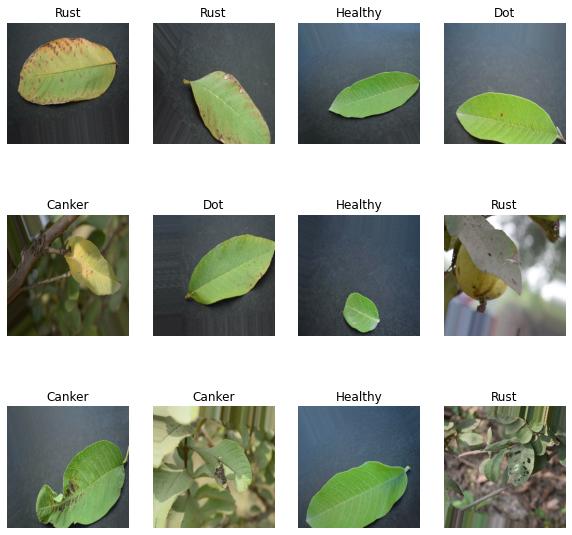

In [7]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in train_data.take(1):
    for i in range(0,12):
        plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        plt.title(class_names[np.argmax(label_batch[i])])
        plt.axis("off")

## Augmented image view

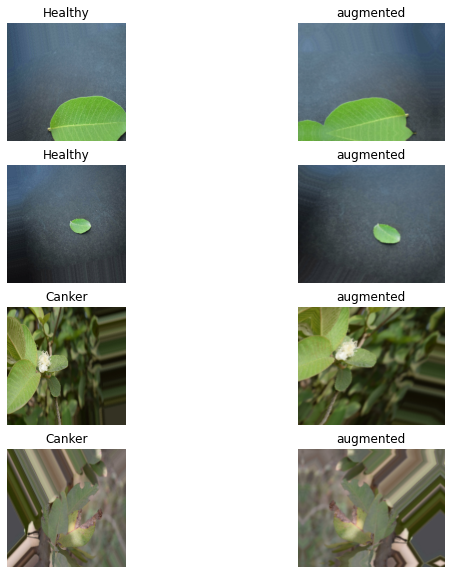

In [8]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in train_data.take(1):
    augmented_image_batch = data_augmentation(image_batch)
    image_plt_len = len(image_batch) if len(image_batch) < 4 else 4
    for i in range(0, image_plt_len):
        plt.subplot(image_plt_len,2,2*i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        plt.title(class_names[np.argmax(label_batch[i])])
        plt.axis("off")
        plt.subplot(image_plt_len,2,2*i+2)
        plt.imshow(augmented_image_batch[i])
        plt.title(f"augmented")
        plt.axis("off")

## Create CheckPoint

In [6]:
checkpoint_path = "CheckPoint/cp.ckpt"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    save_weights_only=True,
    monitor='val_accuracy',
    save_best_only=True
)

# Create model

In [7]:
input_shape = (32, 224, 224, 3)
model = tf.keras.models.Sequential(
    [
        data_augmentation,
        tf.keras.layers.Conv2D(
          filters=64,
          kernel_size=3,
          activation='relu',
          input_shape=input_shape
        ),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPool2D(
          pool_size=2,
          padding='valid'
        ),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPool2D(2),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(len(class_names), activation='softmax')
    ]
)
model.build(input_shape=input_shape)


In [11]:
model.compile(
    loss = 'categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data = test_data,
    validation_steps = len(test_data),
    callbacks = [
        checkpoint_callback,
    ]
)

Epoch 1/20
24/24 [==============================] - 99s 4s/step - loss: 1.5741 - accuracy: 0.2448 - val_loss: 1.5250 - val_accuracy: 0.3065
Epoch 2/20
24/24 [==============================] - 80s 3s/step - loss: 1.4770 - accuracy: 0.3416 - val_loss: 1.4444 - val_accuracy: 0.4138
Epoch 3/20
24/24 [==============================] - 74s 3s/step - loss: 1.3342 - accuracy: 0.4359 - val_loss: 1.4458 - val_accuracy: 0.3448
Epoch 4/20
24/24 [==============================] - 76s 3s/step - loss: 1.2437 - accuracy: 0.4476 - val_loss: 1.2242 - val_accuracy: 0.4636
Epoch 5/20
24/24 [==============================] - 72s 3s/step - loss: 1.1775 - accuracy: 0.5275 - val_loss: 1.1812 - val_accuracy: 0.5096
Epoch 6/20
24/24 [==============================] - 77s 3s/step - loss: 1.1488 - accuracy: 0.5157 - val_loss: 1.2019 - val_accuracy: 0.5057
Epoch 7/20
24/24 [==============================] - 76s 3s/step - loss: 1.1683 - accuracy: 0.5118 - val_loss: 1.1500 - val_accuracy: 0.5632
Epoch 8/20
24/24 [==

## Plot the history

In [14]:
def plot_loss_curves(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()


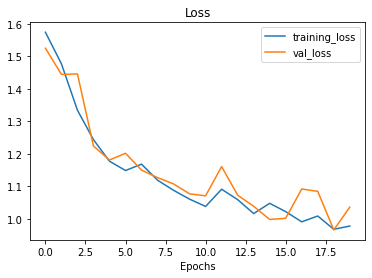

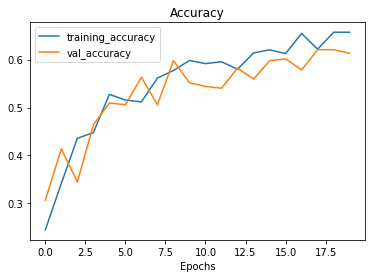

In [15]:
plot_loss_curves(history)

## Check best weight validation data percentance

In [16]:
def bestWeightModelEvaluate(model, weight_path, data):
  cp_model = tf.keras.models.clone_model(model)
  cp_model.compile(
      loss = tf.keras.losses.CategoricalCrossentropy(),
      optimizer = tf.keras.optimizers.Adam(),
      metrics = ['accuracy']
  )
  cp_model.load_weights(weight_path)
  cp_model.evaluate(data)

### Evaluate model

In [17]:
# Train data
model.evaluate(train_data)
# Test data
model.evaluate(test_data)
# Valid data
model.evaluate(valid_data)

8/8 [==============================] - 14s 298ms/step - loss: 0.9457 - accuracy: 0.6431


[0.9457253217697144, 0.6431372761726379]

# Pretraine Model


In [29]:
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3, Xception
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

# Function to create models with advanced architecture
def create_advanced_model(pretrained_model, num_classes, dropout_rate=0.5):
    model = Sequential([
        data_augmentation,
        pretrained_model,  # Base model
        GlobalAveragePooling2D(),  # Global pooling to reduce dimensions
        Dropout(dropout_rate),  # Add Dropout to avoid overfitting
        Dense(1024, activation='relu'),  # Additional Dense layer
        Dropout(dropout_rate),  # Additional Dropout
        Dense(num_classes, activation='softmax')  # Output layer for classification
    ])
    return model


In [30]:
num_classes = len(class_names)

In [30]:
# Load pretrained models without the top classification layer
vgg_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
inception_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
xception_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Create models with advanced architecture and dropout layers
vgg16_advanced_model = create_advanced_model(vgg_model, num_classes)
resnet50_advanced_model = create_advanced_model(resnet_model, num_classes)
inceptionv3_advanced_model = create_advanced_model(inception_model, num_classes)
xception_advanced_model = create_advanced_model(xception_model, num_classes)


83697664/83683744 [==============================] - 0s 0us/step


In [31]:

# Compile and train the Xception advanced model
xception_advanced_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_xception = xception_advanced_model.fit(train_data, validation_data=valid_data, epochs=50, callbacks=[checkpoint_callback])


Epoch 1/50
24/24 [==============================] - 88s 3s/step - loss: 1.5596 - accuracy: 0.3469 - val_loss: 2.3813 - val_accuracy: 0.4549
Epoch 2/50
24/24 [==============================] - 68s 3s/step - loss: 0.8541 - accuracy: 0.6505 - val_loss: 14.0620 - val_accuracy: 0.3804
Epoch 3/50
24/24 [==============================] - 67s 3s/step - loss: 0.5859 - accuracy: 0.8168 - val_loss: 3.8960 - val_accuracy: 0.5451
Epoch 4/50
24/24 [==============================] - 64s 3s/step - loss: 0.6359 - accuracy: 0.8063 - val_loss: 53.2566 - val_accuracy: 0.3529
Epoch 5/50
24/24 [==============================] - 64s 3s/step - loss: 0.3648 - accuracy: 0.8822 - val_loss: 233.1629 - val_accuracy: 0.2431
Epoch 6/50
24/24 [==============================] - 56s 2s/step - loss: 0.3165 - accuracy: 0.8809 - val_loss: 33.4614 - val_accuracy: 0.3686
Epoch 7/50
24/24 [==============================] - 53s 2s/step - loss: 0.2454 - accuracy: 0.9149 - val_loss: 28.2419 - val_accuracy: 0.5294
Epoch 8/50
24/

In [32]:
# Evaluate the Xception advanced model
xception_advanced_model.evaluate(test_data)
xception_advanced_model.evaluate(valid_data)

8/8 [==============================] - 1s 135ms/step - loss: 10.9806 - accuracy: 0.6745


[10.980649948120117, 0.6745098233222961]

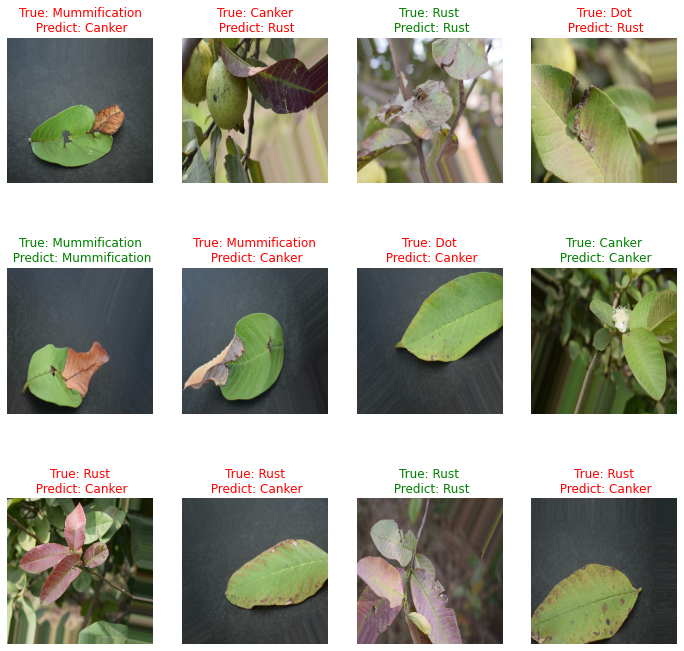

In [33]:
# Visualize predictions for the VGG16 advanced model (repeat similarly for other models)
plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    predictions = xception_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")


In [31]:
import matplotlib.pyplot as plt

# Function to plot accuracy and loss curves
def plot_loss_accuracy(history, model_name):
    # Plot loss
    plt.figure(figsize=(12, 5))
    epochs = range(len(history.history['loss']))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Function to compute and plot the confusion matrix
def plot_confusion_matrix(model, test_data, class_names, model_name):
    # Get true labels and predictions
    y_true = []
    y_pred = []

    for image_batch, label_batch in test_data:
        predictions = model.predict(image_batch)
        predicted_labels = np.argmax(predictions, axis=-1)
        true_labels = np.argmax(label_batch.numpy(), axis=-1)
        
        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()




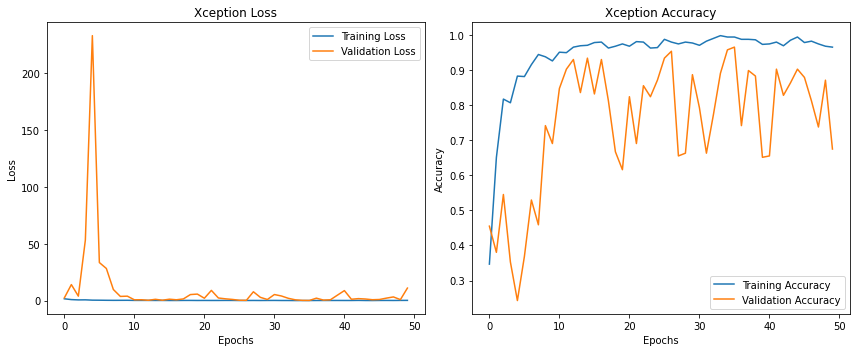

<Figure size 720x576 with 0 Axes>

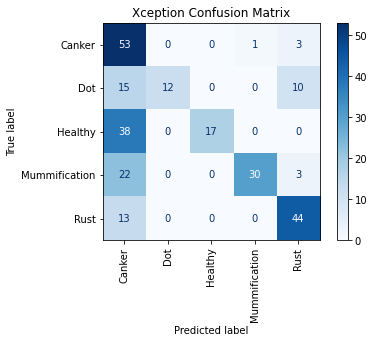

In [36]:
plot_loss_accuracy(history_xception, "Xception")
plot_confusion_matrix(xception_advanced_model, test_data, class_names, "Xception")

In [37]:

# Save the Xception teacher model
xception_advanced_model.save('xception_teacher_model.h5')


/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


Epoch 1/30
24/24 [==============================] - 44s 2s/step - loss: 0.0833 - accuracy: 0.9791 - val_loss: 1.8550 - val_accuracy: 0.8392
Epoch 2/30
24/24 [==============================] - 35s 2s/step - loss: 0.0629 - accuracy: 0.9830 - val_loss: 0.5308 - val_accuracy: 0.9176
Epoch 3/30
24/24 [==============================] - 33s 1s/step - loss: 0.0655 - accuracy: 0.9869 - val_loss: 0.2310 - val_accuracy: 0.9569
Epoch 4/30
24/24 [==============================] - 37s 2s/step - loss: 0.0528 - accuracy: 0.9869 - val_loss: 0.0964 - val_accuracy: 0.9765
Epoch 5/30
24/24 [==============================] - 35s 1s/step - loss: 0.0646 - accuracy: 0.9777 - val_loss: 0.0540 - val_accuracy: 0.9804
Epoch 6/30
24/24 [==============================] - 28s 1s/step - loss: 0.0760 - accuracy: 0.9843 - val_loss: 0.0414 - val_accuracy: 0.9882
Epoch 7/30
24/24 [==============================] - 38s 2s/step - loss: 0.0391 - accuracy: 0.9895 - val_loss: 0.0355 - val_accuracy: 0.9922
Epoch 8/30
24/24 [==

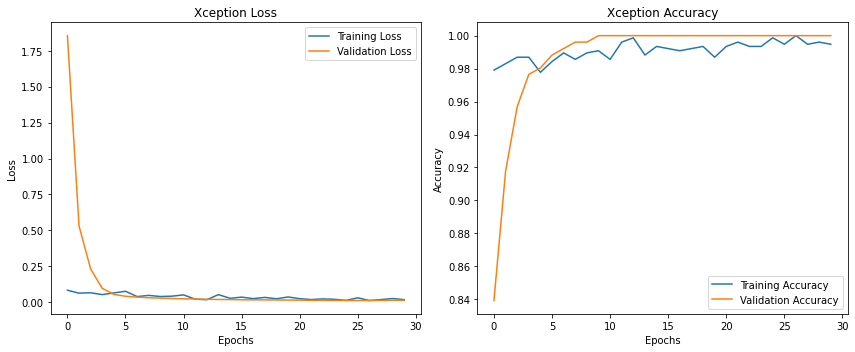

<Figure size 720x576 with 0 Axes>

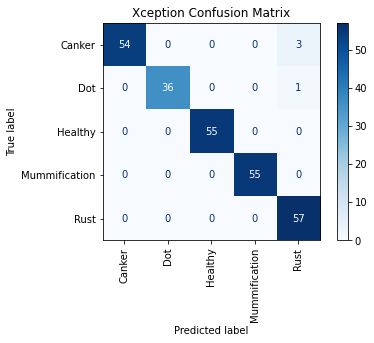

In [38]:
for layer in xception_advanced_model.layers:  # 'base_model' is the MobileNetV2 model
    layer.trainable = True

# Compile again with a lower learning rate for fine-tuning
xception_advanced_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 9: Fine-tune the model
history_xception = xception_advanced_model.fit(train_data, validation_data=valid_data, epochs=30)
# Evaluate the Xception advanced model
xception_advanced_model.evaluate(test_data)
xception_advanced_model.evaluate(valid_data)
plot_loss_accuracy(history_xception, "Xception")
plot_confusion_matrix(xception_advanced_model, test_data, class_names, "Xception")

In [40]:
xception_advanced_model.save('xception_teacher_model.h5')

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


# vgg16

Epoch 1/20
24/24 [==============================] - 135s 6s/step - loss: 1.5977 - accuracy: 0.2003 - val_loss: 1.5968 - val_accuracy: 0.2157
Epoch 2/20
24/24 [==============================] - 131s 5s/step - loss: 1.5975 - accuracy: 0.2160 - val_loss: 1.5850 - val_accuracy: 0.2157
Epoch 3/20
24/24 [==============================] - 146s 6s/step - loss: 1.5717 - accuracy: 0.3089 - val_loss: 1.6004 - val_accuracy: 0.2157
Epoch 4/20
24/24 [==============================] - 138s 6s/step - loss: 1.6158 - accuracy: 0.2212 - val_loss: 1.5998 - val_accuracy: 0.2157
Epoch 5/20
24/24 [==============================] - 135s 5s/step - loss: 1.6117 - accuracy: 0.2317 - val_loss: 1.5940 - val_accuracy: 0.2118
Epoch 6/20
24/24 [==============================] - 125s 5s/step - loss: 1.6058 - accuracy: 0.1990 - val_loss: 1.6002 - val_accuracy: 0.2157
Epoch 7/20
24/24 [==============================] - 112s 5s/step - loss: 1.6108 - accuracy: 0.2251 - val_loss: 1.5967 - val_accuracy: 0.2157
Epoch 8/20
24

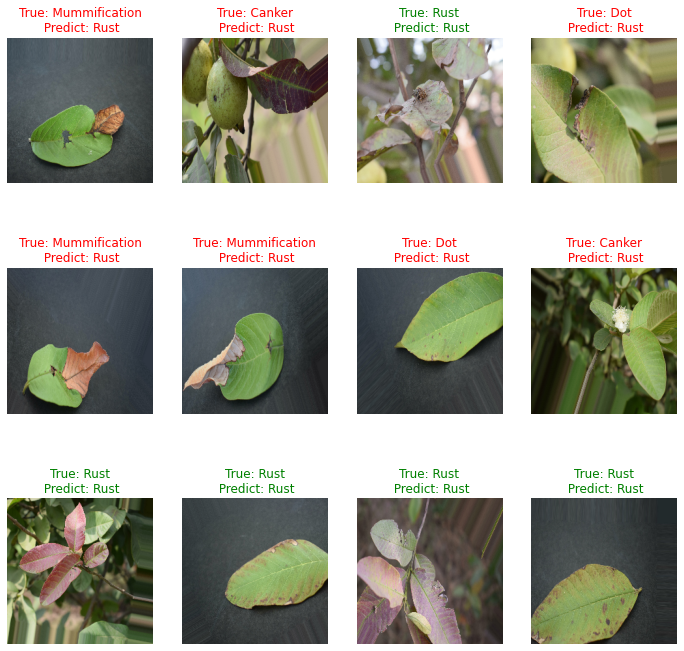

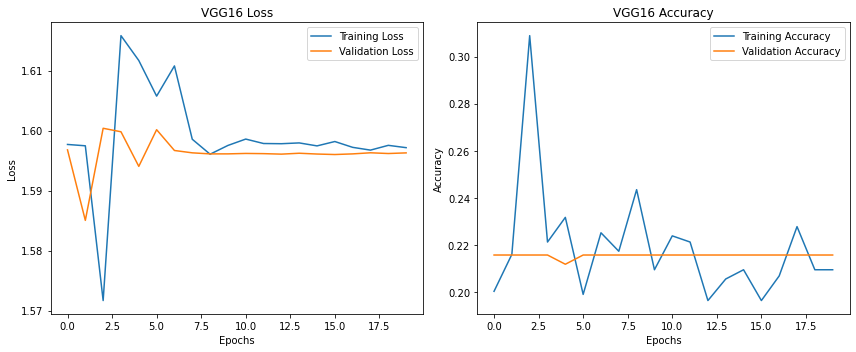

<Figure size 864x576 with 0 Axes>

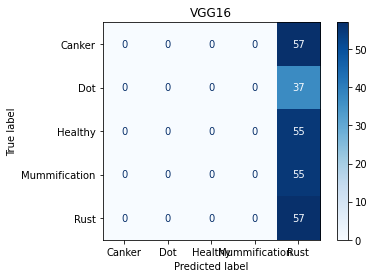

In [62]:
vgg16_advanced_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_vgg = vgg16_advanced_model.fit(train_data, validation_data=valid_data, epochs=20, callbacks=[checkpoint_callback])

vgg16_advanced_model.evaluate(test_data)
vgg16_advanced_model.evaluate(valid_data)

# Visualize predictions for the VGG16 advanced model (repeat similarly for other models)
plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    predictions = vgg16_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")

plot_loss_accuracy(history_vgg, "VGG16")
plot_confusion_matrix(vgg16_advanced_model, test_data, class_names, "VGG16")
vgg16_advanced_model.save('vgg16_advanced_model.h5')

Epoch 1/20
24/24 [==============================] - 94s 4s/step - loss: 1.5974 - accuracy: 0.2160 - val_loss: 1.5963 - val_accuracy: 0.2157
Epoch 2/20
24/24 [==============================] - 118s 5s/step - loss: 1.5976 - accuracy: 0.2225 - val_loss: 1.5963 - val_accuracy: 0.2157
Epoch 3/20
24/24 [==============================] - 110s 5s/step - loss: 1.5974 - accuracy: 0.2199 - val_loss: 1.5963 - val_accuracy: 0.2157
Epoch 4/20
24/24 [==============================] - 109s 5s/step - loss: 1.5959 - accuracy: 0.2173 - val_loss: 1.5963 - val_accuracy: 0.2157
Epoch 5/20
24/24 [==============================] - 89s 4s/step - loss: 1.5973 - accuracy: 0.2094 - val_loss: 1.5963 - val_accuracy: 0.2157
Epoch 6/20
24/24 [==============================] - 94s 4s/step - loss: 1.5967 - accuracy: 0.2199 - val_loss: 1.5963 - val_accuracy: 0.2157
Epoch 7/20
24/24 [==============================] - 124s 5s/step - loss: 1.5973 - accuracy: 0.2277 - val_loss: 1.5963 - val_accuracy: 0.2157
Epoch 8/20
24/24

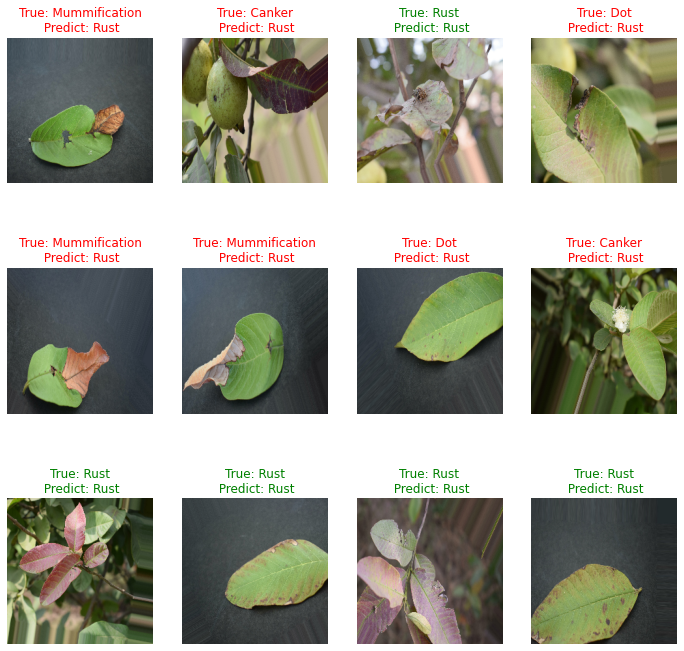

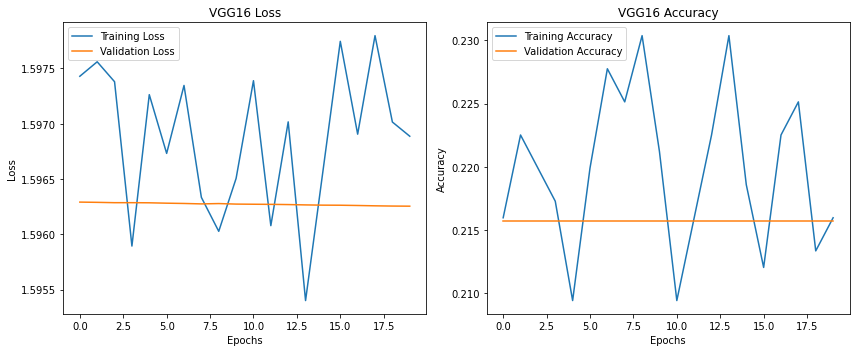

<Figure size 864x576 with 0 Axes>

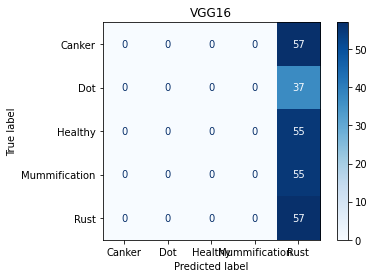

In [63]:
for layer in vgg16_advanced_model.layers:  # 'base_model' is the MobileNetV2 model
    layer.trainable = True

# Compile again with a lower learning rate for fine-tuning
vgg16_advanced_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 9: Fine-tune the model
history_vgg = vgg16_advanced_model.fit(train_data, validation_data=valid_data, epochs=20)
vgg16_advanced_model.evaluate(test_data)
vgg16_advanced_model.evaluate(valid_data)

# Visualize predictions for the VGG16 advanced model (repeat similarly for other models)
plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    predictions = vgg16_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")

plot_loss_accuracy(history_vgg, "VGG16")
plot_confusion_matrix(vgg16_advanced_model, test_data, class_names, "VGG16")
vgg16_advanced_model.save('vgg16_advanced_model.h5')


# resnrt50

Epoch 1/30
24/24 [==============================] - 66s 3s/step - loss: 1.6576 - accuracy: 0.5733 - val_loss: 979.3047 - val_accuracy: 0.2157
Epoch 2/30
24/24 [==============================] - 44s 2s/step - loss: 1.0932 - accuracy: 0.6754 - val_loss: 259636.3438 - val_accuracy: 0.2157
Epoch 3/30
24/24 [==============================] - 38s 2s/step - loss: 0.9914 - accuracy: 0.6911 - val_loss: 3910.2515 - val_accuracy: 0.2157
Epoch 4/30
24/24 [==============================] - 39s 2s/step - loss: 0.7709 - accuracy: 0.7605 - val_loss: 2.5840 - val_accuracy: 0.2157
Epoch 5/30
24/24 [==============================] - 30s 1s/step - loss: 0.5829 - accuracy: 0.7984 - val_loss: 2.3136 - val_accuracy: 0.2157
Epoch 6/30
24/24 [==============================] - 30s 1s/step - loss: 0.5420 - accuracy: 0.7866 - val_loss: 1.6220 - val_accuracy: 0.1373
Epoch 7/30
24/24 [==============================] - 27s 1s/step - loss: 0.6623 - accuracy: 0.7814 - val_loss: 1.6876 - val_accuracy: 0.1373
Epoch 8/30

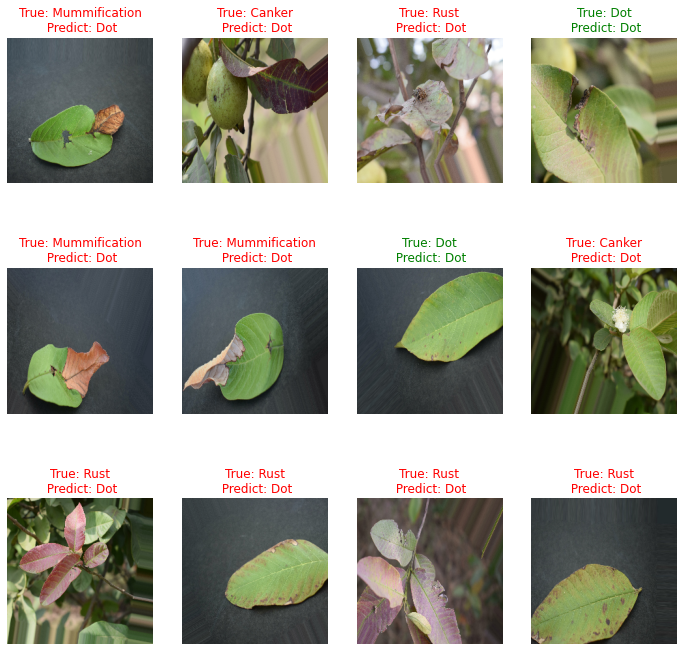

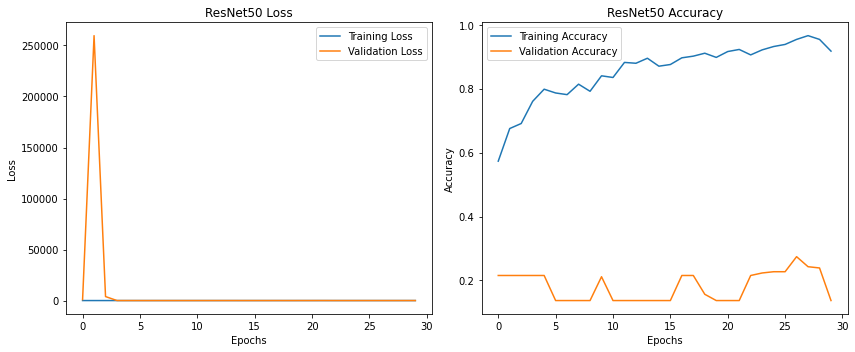

<Figure size 864x576 with 0 Axes>

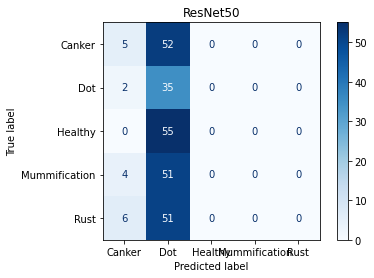

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [64]:
resnet50_advanced_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_resnet = resnet50_advanced_model.fit(train_data, validation_data=valid_data, epochs=30, callbacks=[checkpoint_callback])

resnet50_advanced_model.evaluate(test_data)
resnet50_advanced_model.evaluate(valid_data)

plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    predictions = resnet50_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")

plot_loss_accuracy(history_resnet, "ResNet50")
plot_confusion_matrix(resnet50_advanced_model, test_data, class_names, "ResNet50")
resnet50_advanced_model.save('resnet50_advanced_model.h5')

Epoch 1/20
24/24 [==============================] - 22s 707ms/step - loss: 0.2782 - accuracy: 0.8927 - val_loss: 8.9670 - val_accuracy: 0.1451
Epoch 2/20
24/24 [==============================] - 15s 636ms/step - loss: 0.1950 - accuracy: 0.9267 - val_loss: 8.7139 - val_accuracy: 0.1922
Epoch 3/20
24/24 [==============================] - 14s 589ms/step - loss: 0.1570 - accuracy: 0.9555 - val_loss: 8.5667 - val_accuracy: 0.2118
Epoch 4/20
24/24 [==============================] - 16s 666ms/step - loss: 0.1511 - accuracy: 0.9411 - val_loss: 8.6410 - val_accuracy: 0.2157
Epoch 5/20
24/24 [==============================] - 23s 986ms/step - loss: 0.1157 - accuracy: 0.9594 - val_loss: 8.6696 - val_accuracy: 0.2157
Epoch 6/20
24/24 [==============================] - 15s 610ms/step - loss: 0.1511 - accuracy: 0.9581 - val_loss: 8.5661 - val_accuracy: 0.2196
Epoch 7/20
24/24 [==============================] - 14s 586ms/step - loss: 0.1178 - accuracy: 0.9634 - val_loss: 8.4477 - val_accuracy: 0.2196

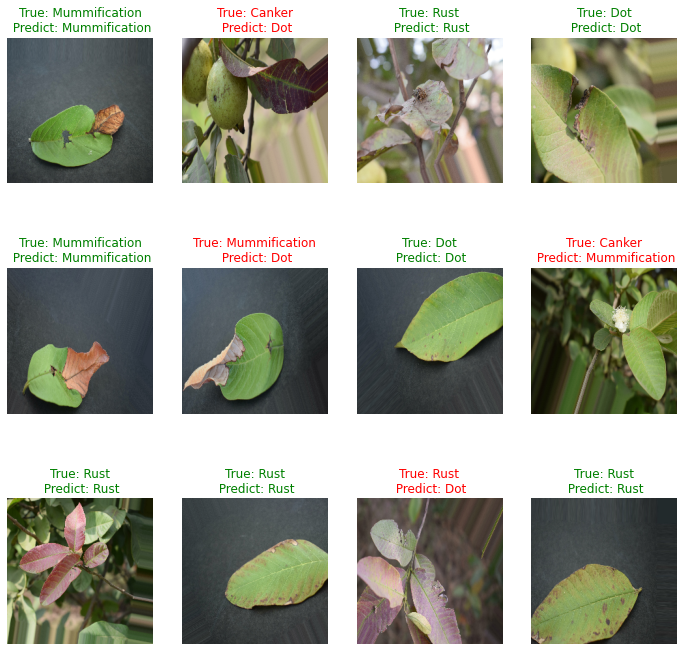

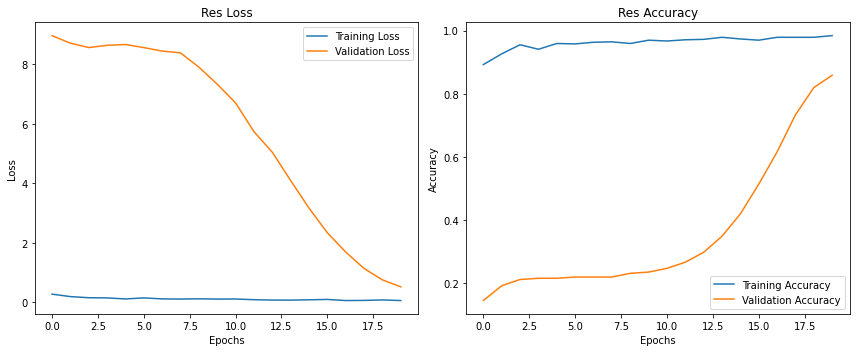

<Figure size 864x576 with 0 Axes>

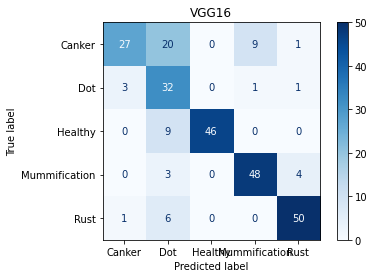

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [65]:
for layer in resnet50_advanced_model.layers:  # 'base_model' is the MobileNetV2 model
    layer.trainable = True

# Compile again with a lower learning rate for fine-tuning
resnet50_advanced_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 9: Fine-tune the model
history_resnet = resnet50_advanced_model.fit(train_data, validation_data=valid_data, epochs=20)
resnet50_advanced_model.evaluate(test_data)
resnet50_advanced_model.evaluate(valid_data)

# Visualize predictions for the VGG16 advanced model (repeat similarly for other models)
plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    predictions = resnet50_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")

plot_loss_accuracy(history_resnet, "Res")
plot_confusion_matrix(resnet50_advanced_model, test_data, class_names, "VGG16")
resnet50_advanced_model.save('resnet50_advanced_model.h5')

# Inceptionv3

Epoch 1/30
24/24 [==============================] - 74s 3s/step - loss: 1.4126 - accuracy: 0.4817 - val_loss: 50.1179 - val_accuracy: 0.2157
Epoch 2/30
24/24 [==============================] - 48s 2s/step - loss: 0.7611 - accuracy: 0.7291 - val_loss: 9.0838 - val_accuracy: 0.3725
Epoch 3/30
24/24 [==============================] - 51s 2s/step - loss: 0.5851 - accuracy: 0.7984 - val_loss: 18.6740 - val_accuracy: 0.4235
Epoch 4/30
24/24 [==============================] - 38s 2s/step - loss: 0.5547 - accuracy: 0.8037 - val_loss: 7.2454 - val_accuracy: 0.2471
Epoch 5/30
24/24 [==============================] - 39s 2s/step - loss: 0.4158 - accuracy: 0.8560 - val_loss: 22.5384 - val_accuracy: 0.2157
Epoch 6/30
24/24 [==============================] - 37s 2s/step - loss: 0.4506 - accuracy: 0.8455 - val_loss: 9.2977 - val_accuracy: 0.5137
Epoch 7/30
24/24 [==============================] - 37s 2s/step - loss: 0.3980 - accuracy: 0.8743 - val_loss: 5.3138 - val_accuracy: 0.3255
Epoch 8/30
24/24 

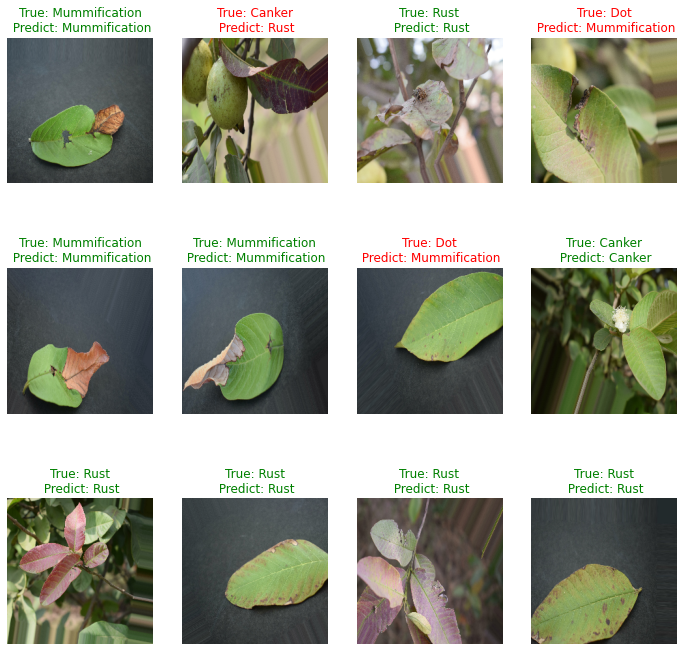

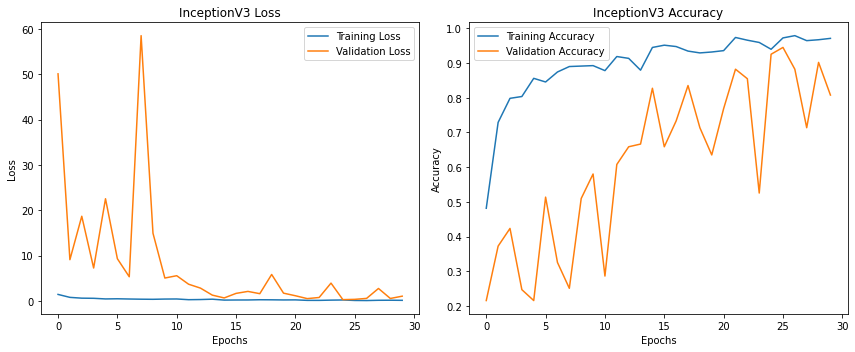

<Figure size 864x576 with 0 Axes>

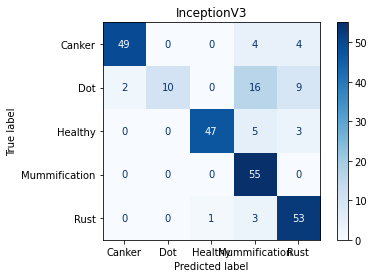

In [66]:
inceptionv3_advanced_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history_inception = inceptionv3_advanced_model.fit(train_data, validation_data=valid_data, epochs=30, callbacks=[checkpoint_callback])


inceptionv3_advanced_model.evaluate(test_data)
inceptionv3_advanced_model.evaluate(valid_data)

# Visualize predictions for the VGG16 advanced model (repeat similarly for other models)
plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    predictions = inceptionv3_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")


plot_loss_accuracy(history_inception, "InceptionV3")
plot_confusion_matrix(inceptionv3_advanced_model, test_data, class_names, "InceptionV3")
inceptionv3_advanced_model.save('inceptionv3_advanced_model.h5')


Epoch 1/20
24/24 [==============================] - 31s 994ms/step - loss: 0.0724 - accuracy: 0.9764 - val_loss: 0.5992 - val_accuracy: 0.8588
Epoch 2/20
24/24 [==============================] - 26s 986ms/step - loss: 0.0479 - accuracy: 0.9869 - val_loss: 0.4219 - val_accuracy: 0.9059
Epoch 3/20
24/24 [==============================] - 20s 838ms/step - loss: 0.0510 - accuracy: 0.9817 - val_loss: 0.3193 - val_accuracy: 0.9255
Epoch 4/20
24/24 [==============================] - 22s 849ms/step - loss: 0.0425 - accuracy: 0.9908 - val_loss: 0.2414 - val_accuracy: 0.9255
Epoch 5/20
24/24 [==============================] - 22s 904ms/step - loss: 0.0396 - accuracy: 0.9921 - val_loss: 0.2076 - val_accuracy: 0.9373
Epoch 6/20
24/24 [==============================] - 16s 648ms/step - loss: 0.0359 - accuracy: 0.9908 - val_loss: 0.1678 - val_accuracy: 0.9490
Epoch 7/20
24/24 [==============================] - 20s 812ms/step - loss: 0.0219 - accuracy: 0.9974 - val_loss: 0.1595 - val_accuracy: 0.9569

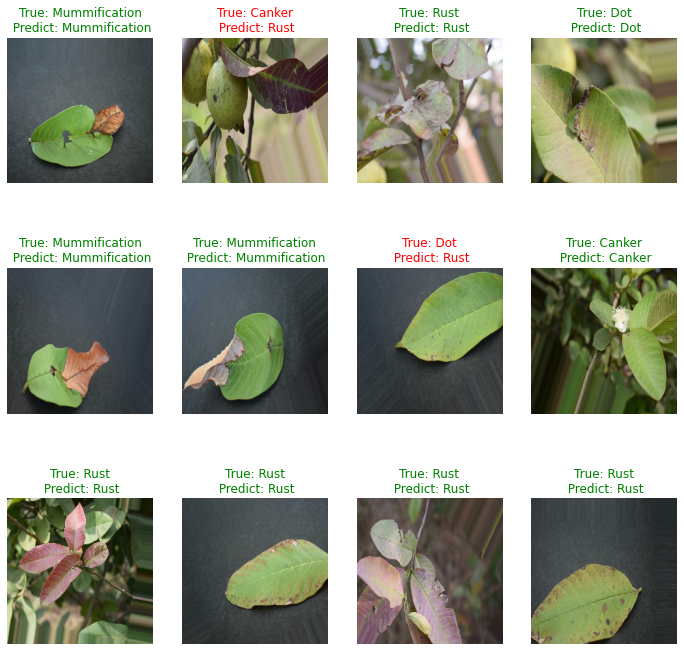

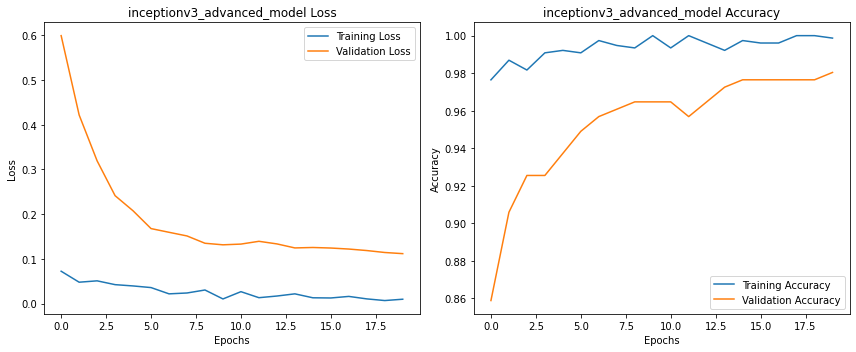

<Figure size 864x576 with 0 Axes>

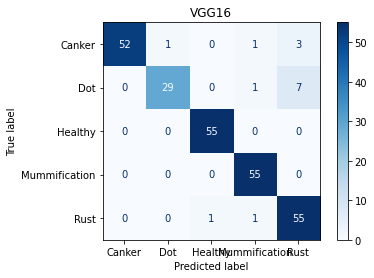

In [67]:
for layer in resnet50_advanced_model.layers:  # 'base_model' is the MobileNetV2 model
    layer.trainable = True

# Compile again with a lower learning rate for fine-tuning
inceptionv3_advanced_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 9: Fine-tune the model
history_inception = inceptionv3_advanced_model.fit(train_data, validation_data=valid_data, epochs=20)
inceptionv3_advanced_model.evaluate(test_data)
inceptionv3_advanced_model.evaluate(valid_data)

# Visualize predictions for the VGG16 advanced model (repeat similarly for other models)
plt.figure(figsize=(12,12))
for image_batch,label_batch in test_data.take(1):
    predictions = inceptionv3_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")

plot_loss_accuracy(history_inception, "inceptionv3_advanced_model")
plot_confusion_matrix(inceptionv3_advanced_model, test_data, class_names, "VGG16")
inceptionv3_advanced_model.save('inceptionv3_advanced_model.h5')

# Inception res

Epoch 1/30
24/24 [==============================] - 93s 3s/step - loss: 1.0316 - accuracy: 0.6270 - val_loss: 35.8588 - val_accuracy: 0.1373
Epoch 2/30
24/24 [==============================] - 59s 2s/step - loss: 0.6444 - accuracy: 0.7788 - val_loss: 5774.5596 - val_accuracy: 0.2157
Epoch 3/30
24/24 [==============================] - 48s 2s/step - loss: 0.5199 - accuracy: 0.8128 - val_loss: 37.1224 - val_accuracy: 0.3725
Epoch 4/30
24/24 [==============================] - 65s 3s/step - loss: 0.3885 - accuracy: 0.8613 - val_loss: 111.8060 - val_accuracy: 0.5176
Epoch 5/30
24/24 [==============================] - 58s 2s/step - loss: 0.3072 - accuracy: 0.8940 - val_loss: 4.6901 - val_accuracy: 0.7412
Epoch 6/30
24/24 [==============================] - 47s 2s/step - loss: 0.4198 - accuracy: 0.8730 - val_loss: 14.5132 - val_accuracy: 0.5529
Epoch 7/30
24/24 [==============================] - 42s 2s/step - loss: 0.4103 - accuracy: 0.8534 - val_loss: 32.3283 - val_accuracy: 0.5451
Epoch 8/30


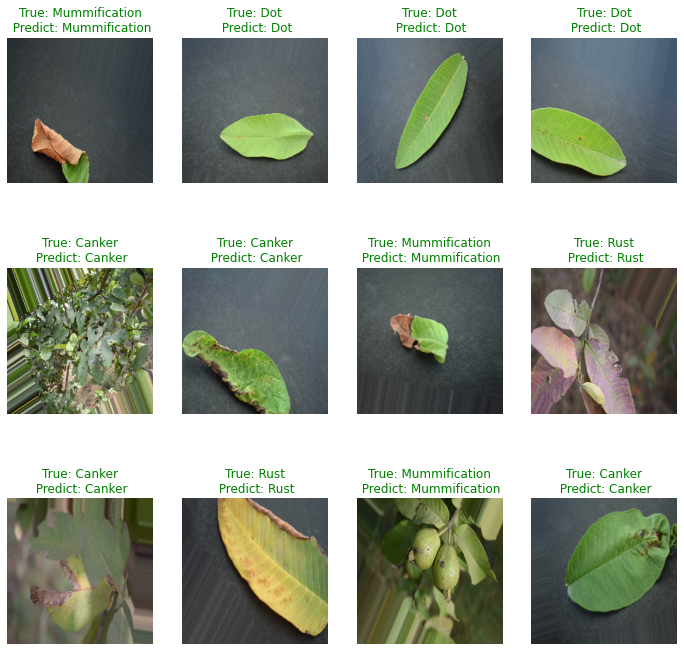

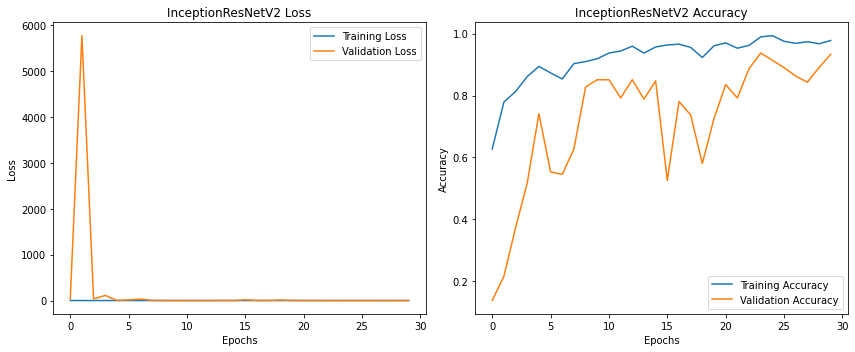

<Figure size 720x576 with 0 Axes>

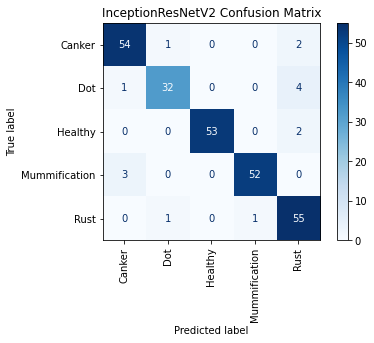

Epoch 1/20
24/24 [==============================] - 48s 1s/step - loss: 0.0394 - accuracy: 0.9843 - val_loss: 0.1767 - val_accuracy: 0.9569
Epoch 2/20
24/24 [==============================] - 26s 1s/step - loss: 0.0234 - accuracy: 0.9935 - val_loss: 0.1345 - val_accuracy: 0.9686
Epoch 3/20
24/24 [==============================] - 29s 1s/step - loss: 0.0263 - accuracy: 0.9935 - val_loss: 0.1218 - val_accuracy: 0.9686
Epoch 4/20
24/24 [==============================] - 32s 1s/step - loss: 0.0212 - accuracy: 0.9948 - val_loss: 0.1107 - val_accuracy: 0.9647
Epoch 5/20
24/24 [==============================] - 24s 1s/step - loss: 0.0300 - accuracy: 0.9948 - val_loss: 0.0931 - val_accuracy: 0.9647
Epoch 6/20
24/24 [==============================] - 29s 1s/step - loss: 0.0148 - accuracy: 0.9961 - val_loss: 0.0854 - val_accuracy: 0.9686
Epoch 7/20
24/24 [==============================] - 26s 1s/step - loss: 0.0126 - accuracy: 0.9974 - val_loss: 0.0858 - val_accuracy: 0.9608
Epoch 8/20
24/24 [==

NameError: name 'inceptionv3_advanced_model' is not defined

In [33]:
from tensorflow.keras.applications import InceptionResNetV2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load the base InceptionResNetV2 model with pretrained ImageNet weights
inception_resnet_model = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Assuming you already have the function 'create_advanced_model'
inception_resnet_advanced_model = create_advanced_model(inception_resnet_model, num_classes)

# Compile the InceptionResNetV2 advanced model
inception_resnet_advanced_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history_inception_resnet = inception_resnet_advanced_model.fit(train_data, validation_data=valid_data, epochs=30, callbacks=[checkpoint_callback])

# Evaluate on test data
inception_resnet_advanced_model.evaluate(test_data)
inception_resnet_advanced_model.evaluate(valid_data)

# Visualize predictions for the InceptionResNetV2 advanced model
plt.figure(figsize=(12, 12))
for image_batch, label_batch in test_data.take(1):
    predictions = inception_resnet_advanced_model.predict(image_batch)
    predictions = np.argmax(predictions, axis=-1)
    for i in range(0, len(predictions) if len(predictions) < 12 else 12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype("uint32"))
        true_class = class_names[np.argmax(label_batch[i])]
        predict_class = class_names[predictions[i]]
        title = f"True: {true_class}\n Predict: {predict_class}"
        plt.title(title, color='g' if true_class == predict_class else 'r')
        plt.axis("off")

# Plot loss and accuracy graphs for InceptionResNetV2
plot_loss_accuracy(history_inception_resnet, "InceptionResNetV2")

# Plot confusion matrix for InceptionResNetV2
plot_confusion_matrix(inception_resnet_advanced_model, test_data, class_names, "InceptionResNetV2")

# Save the InceptionResNetV2 advanced model
inception_resnet_advanced_model.save('inception_resnet_advanced_model.h5')



for layer in inception_resnet_advanced_model.layers:  # 'base_model' is the MobileNetV2 model
    layer.trainable = True

# Compile again with a lower learning rate for fine-tuning
inception_resnet_advanced_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 9: Fine-tune the model
history_inception_resnet = inception_resnet_advanced_model.fit(train_data, validation_data=valid_data, epochs=20)
inception_resnet_advanced_model.evaluate(test_data)
inception_resnet_advanced_model.evaluate(valid_data)

plot_loss_accuracy(history_inception_resnet, "InceptionResNetV2")
plot_confusion_matrix(inception_resnet_advanced_model, test_data, class_names, "InceptionResNetV2")
inception_resnet_advanced_model.save('inception_resnet_advanced_model.h5')

Epoch 1/10
24/24 [==============================] - 23s 965ms/step - loss: 0.0093 - accuracy: 0.9974 - val_loss: 0.0929 - val_accuracy: 0.9608
Epoch 2/10
24/24 [==============================] - 24s 1s/step - loss: 0.0023 - accuracy: 1.0000 - val_loss: 0.0902 - val_accuracy: 0.9686
Epoch 3/10
24/24 [==============================] - 23s 962ms/step - loss: 0.0040 - accuracy: 0.9987 - val_loss: 0.0851 - val_accuracy: 0.9686
Epoch 4/10
24/24 [==============================] - 26s 1s/step - loss: 0.0080 - accuracy: 0.9987 - val_loss: 0.0866 - val_accuracy: 0.9686
Epoch 5/10
24/24 [==============================] - 25s 1s/step - loss: 0.0073 - accuracy: 0.9987 - val_loss: 0.0851 - val_accuracy: 0.9686
Epoch 6/10
24/24 [==============================] - 23s 991ms/step - loss: 0.0035 - accuracy: 1.0000 - val_loss: 0.0873 - val_accuracy: 0.9647
Epoch 7/10
24/24 [==============================] - 24s 1s/step - loss: 0.0027 - accuracy: 1.0000 - val_loss: 0.0887 - val_accuracy: 0.9647
Epoch 8/10


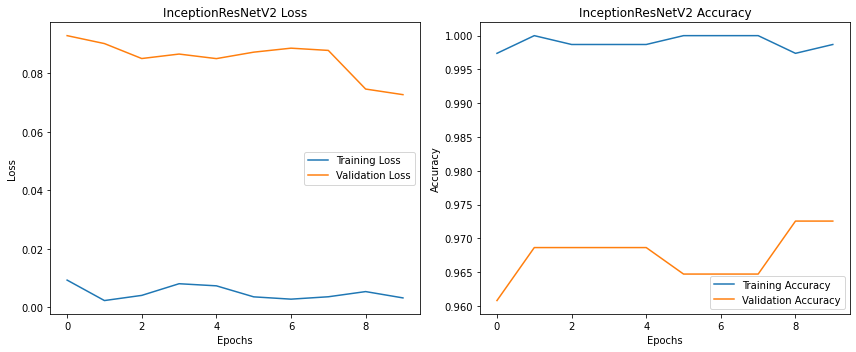

<Figure size 720x576 with 0 Axes>

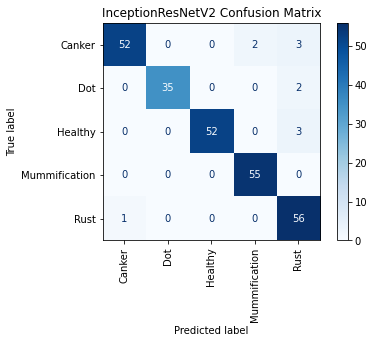

In [34]:
history_inception_resnet = inception_resnet_advanced_model.fit(train_data, validation_data=valid_data, epochs=10)
inception_resnet_advanced_model.evaluate(test_data)
inception_resnet_advanced_model.evaluate(valid_data)

plot_loss_accuracy(history_inception_resnet, "InceptionResNetV2")
plot_confusion_matrix(inception_resnet_advanced_model, test_data, class_names, "InceptionResNetV2")
inception_resnet_advanced_model.save('inception_resnet_advanced_model.h5')

In [14]:
teacher_model = tf.keras.models.load_model('/kaggle/input/xception3/xception_teacher_model (1).h5')
teacher_loss, teacher_accuracy = teacher_model.evaluate(valid_data, verbose=1)

# Print the accuracy
print(f"Teacher Model Accuracy: {teacher_accuracy * 100:.2f}%")


8/8 [==============================] - 2s 120ms/step - loss: 0.0158 - accuracy: 1.0000
Teacher Model Accuracy: 100.00%


# KD

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.experimental.preprocessing.RandomFlip("horizontal", input_shape=(224, 224, 3)),
    tf.keras.layers.experimental.preprocessing.RandomRotation(0.2),
    tf.keras.layers.experimental.preprocessing.RandomZoom(0.2),
    tf.keras.layers.experimental.preprocessing.RandomHeight(0.2),
    tf.keras.layers.experimental.preprocessing.RandomWidth(0.2),
    tf.keras.layers.experimental.preprocessing.Rescaling(1./255),
    tf.keras.layers.experimental.preprocessing.Resizing(224, 224)  # Ensure resizing after augmentation
], name="data_augmentation")


In [9]:
# Custom distillation loss function
def distillation_loss(y_true, y_pred, teacher_pred, alpha=0.2, temperature=5):
    # Hard loss (true labels)
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    
    # Soft loss (teacher's soft predictions)
    teacher_pred = tf.nn.softmax(teacher_pred / temperature)
    student_pred = tf.nn.softmax(y_pred / temperature)
    soft_loss = tf.keras.losses.categorical_crossentropy(teacher_pred, student_pred)
    
    return alpha * hard_loss + (1 - alpha) * soft_loss

# cnn


In [76]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define a simple CNN model
def build_cnn_model(input_shape, num_classes):
    model = tf.keras.models.Sequential([
        data_augmentation,
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Get the input shape and number of classes from your dataset
input_shape = (224, 224, 3)
num_classes = len(class_names)  # Assuming `class_names` contains your class labels

# Build and compile the CNN model
cnn_model = build_cnn_model(input_shape, num_classes)
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history = cnn_model.fit(train_data, validation_data=valid_data, epochs=20)

# Evaluate the CNN model
cnn_accuracy = cnn_model.evaluate(valid_data)
print(f"CNN Model Accuracy: {cnn_accuracy[1] * 100:.2f}%")


Epoch 1/20
24/24 [==============================] - 3s 60ms/step - loss: 1.7458 - accuracy: 0.2762 - val_loss: 1.4107 - val_accuracy: 0.4902
Epoch 2/20
24/24 [==============================] - 1s 54ms/step - loss: 1.3564 - accuracy: 0.4372 - val_loss: 1.2909 - val_accuracy: 0.4588
Epoch 3/20
24/24 [==============================] - 1s 53ms/step - loss: 1.2107 - accuracy: 0.5249 - val_loss: 1.0043 - val_accuracy: 0.6000
Epoch 4/20
24/24 [==============================] - 1s 53ms/step - loss: 1.1926 - accuracy: 0.5288 - val_loss: 1.1384 - val_accuracy: 0.5059
Epoch 5/20
24/24 [==============================] - 1s 53ms/step - loss: 1.0834 - accuracy: 0.5681 - val_loss: 0.9399 - val_accuracy: 0.5922
Epoch 6/20
24/24 [==============================] - 1s 53ms/step - loss: 0.9695 - accuracy: 0.6322 - val_loss: 0.9099 - val_accuracy: 0.6431
Epoch 7/20
24/24 [==============================] - 1s 53ms/step - loss: 0.9172 - accuracy: 0.6571 - val_loss: 0.9346 - val_accuracy: 0.6196
Epoch 8/20
24

8/8 [==============================] - 0s 15ms/step - loss: 0.6527 - accuracy: 0.7294
CNN Model Accuracy (without KD): 72.94%


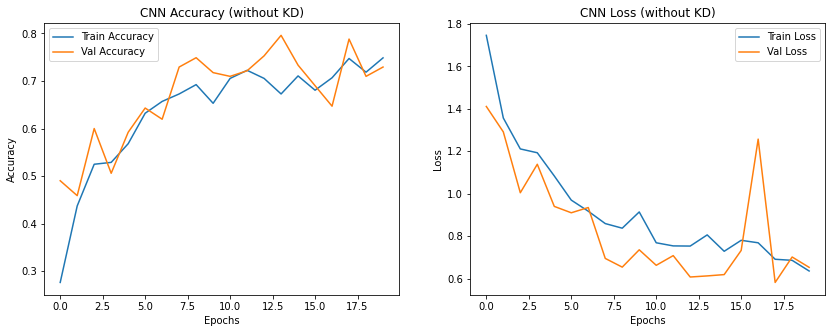

<Figure size 864x576 with 0 Axes>

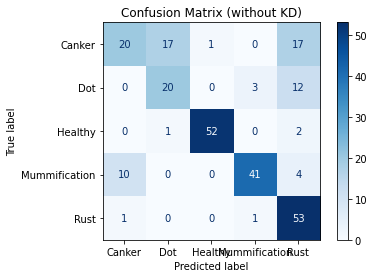

In [77]:
# Step 2: Evaluate the CNN model without KD
cnn_accuracy = cnn_model.evaluate(valid_data)
print(f"CNN Model Accuracy (without KD): {cnn_accuracy[1] * 100:.2f}%")

# Step 3: Plot Accuracy and Loss graphs for CNN without KD
def plot_accuracy_and_loss_without_kd(history):
    plt.figure(figsize=(14, 5))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('CNN Accuracy (without KD)')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('CNN Loss (without KD)')
    plt.legend()

    plt.show()

# Call the plot function for CNN without KD
plot_accuracy_and_loss_without_kd(cnn_history)

# Step 4: Plot Confusion Matrix for CNN without KD
def plot_confusion_matrix_without_kd(model, test_data, class_names):
    # Get true labels and predicted labels
    true_labels = np.concatenate([y for x, y in test_data], axis=0)
    predictions = model.predict(test_data)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(true_labels, axis=1)
    
    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    
    # Plot confusion matrix
    plt.figure(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Confusion Matrix (without KD)")
    plt.show()

# Call the function to plot confusion matrix for CNN without KD
plot_confusion_matrix_without_kd(cnn_model, valid_data, class_names)

In [11]:

student_model = tf.keras.models.load_model('/kaggle/input/student-models/cnn_student_model.h5')
student_accuracy = student_model.evaluate(valid_data)
print(f"Loaded Student Model Accuracy: {student_accuracy[1] * 100:.2f}%")


8/8 [==============================] - 21s 68ms/step - loss: 0.6038 - accuracy: 0.7608
Loaded Student Model Accuracy: 76.08%


Epoch 1/50
Epoch 1 - Train Accuracy: 76.13%, Validation Accuracy: 77.01%
Epoch 2/50
Epoch 2 - Train Accuracy: 78.09%, Validation Accuracy: 72.03%
Epoch 3/50
Epoch 3 - Train Accuracy: 77.83%, Validation Accuracy: 71.26%
Epoch 4/50
Epoch 4 - Train Accuracy: 76.06%, Validation Accuracy: 73.95%
Epoch 5/50
Epoch 5 - Train Accuracy: 79.11%, Validation Accuracy: 73.95%
Epoch 6/50
Epoch 6 - Train Accuracy: 78.12%, Validation Accuracy: 77.78%
Epoch 7/50
Epoch 7 - Train Accuracy: 79.26%, Validation Accuracy: 77.01%
Epoch 8/50
Epoch 8 - Train Accuracy: 77.85%, Validation Accuracy: 76.63%
Epoch 9/50
Epoch 9 - Train Accuracy: 77.66%, Validation Accuracy: 73.56%
Epoch 10/50
Epoch 10 - Train Accuracy: 79.56%, Validation Accuracy: 78.16%
Epoch 11/50
Epoch 11 - Train Accuracy: 79.50%, Validation Accuracy: 75.86%
Epoch 12/50
Epoch 12 - Train Accuracy: 79.15%, Validation Accuracy: 80.46%
Epoch 13/50
Epoch 13 - Train Accuracy: 78.72%, Validation Accuracy: 75.10%
Epoch 14/50
Epoch 14 - Train Accuracy: 79.0

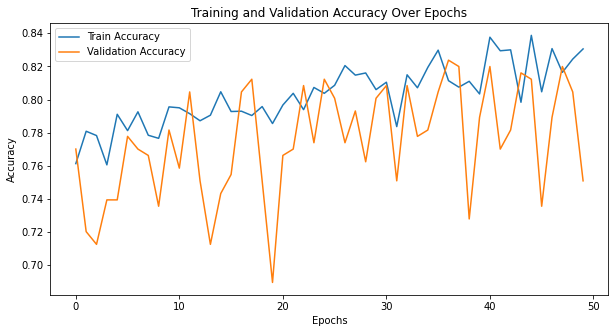

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Variables to track training and validation accuracy and loss
train_acc = []
val_acc = []

# Compile the student model
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Training loop for knowledge distillation
epochs =50
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    
    total_train_acc = 0
    num_batches = 0
    
    for batch, (x_batch_train, y_batch_train) in enumerate(train_data):
        # Get the soft labels from the teacher (Xception model)
        teacher_predictions = teacher_model.predict(x_batch_train)

        # Train the student model using both soft and hard labels
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = distillation_loss(y_batch_train, student_predictions, teacher_predictions)

        # Apply gradients to update the model's weights
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Calculate training accuracy for the batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Calculate average training accuracy for the epoch
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Evaluate the student model on the validation set
    val_loss, val_accuracy = student_model.evaluate(test_data, verbose=0)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Step 2: Plot Accuracy Graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Plot accuracy
plot_accuracy(train_acc, val_acc)


<Figure size 864x576 with 0 Axes>

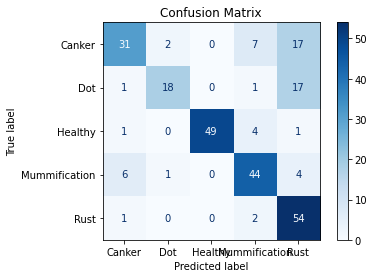

In [18]:
# Step 3: Plot Confusion Matrix
def plot_confusion_matrix(model, test_data, class_names):
    # Get true labels and predicted labels
    true_labels = np.concatenate([y for x, y in test_data], axis=0)
    predictions = model.predict(test_data)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(true_labels, axis=1)
    
    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)
    
    # Plot confusion matrix
    plt.figure(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title("Confusion Matrix")
    plt.show()

# Call the confusion matrix plotting function
plot_confusion_matrix(student_model, test_data, class_names)


# MobaileNet

Epoch 1/50
28/28 [==============================] - 79s 815ms/step - loss: 3.1918 - accuracy: 0.2168 - val_loss: 2.8020 - val_accuracy: 0.2174
Epoch 2/50
28/28 [==============================] - 6s 217ms/step - loss: 2.9759 - accuracy: 0.2648 - val_loss: 2.7103 - val_accuracy: 0.3378
Epoch 3/50
28/28 [==============================] - 6s 217ms/step - loss: 2.8206 - accuracy: 0.3363 - val_loss: 2.7139 - val_accuracy: 0.3411
Epoch 4/50
28/28 [==============================] - 6s 220ms/step - loss: 2.6420 - accuracy: 0.3944 - val_loss: 2.7460 - val_accuracy: 0.3445
Epoch 5/50
28/28 [==============================] - 6s 219ms/step - loss: 2.5465 - accuracy: 0.4480 - val_loss: 2.7605 - val_accuracy: 0.3478
Epoch 6/50
28/28 [==============================] - 6s 217ms/step - loss: 2.4890 - accuracy: 0.4860 - val_loss: 2.7693 - val_accuracy: 0.3512
Epoch 7/50
28/28 [==============================] - 6s 221ms/step - loss: 2.4048 - accuracy: 0.5162 - val_loss: 2.8187 - val_accuracy: 0.3512
Epoch

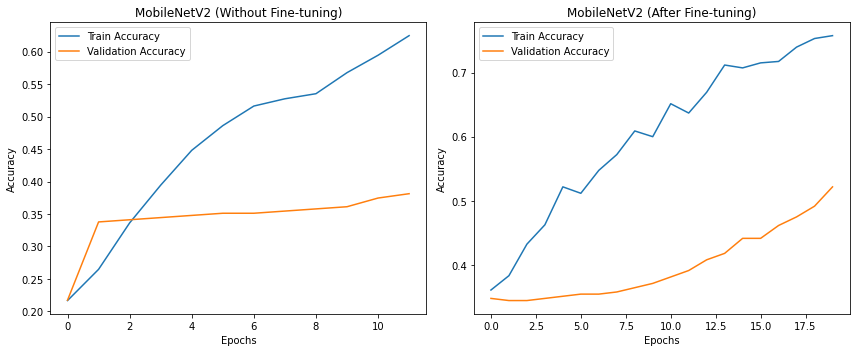

<Figure size 864x576 with 0 Axes>

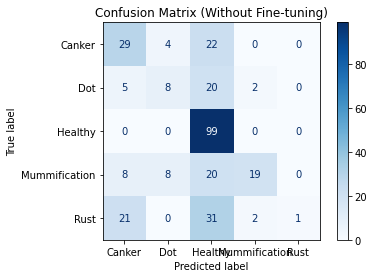

<Figure size 864x576 with 0 Axes>

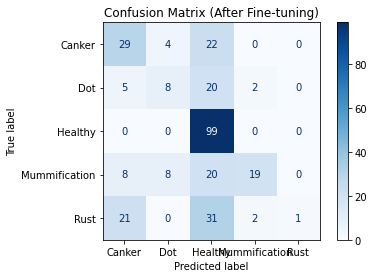

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense, Resizing
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Step 1: Define the MobileNetV2-based student model with resizing
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Input layer that can handle any input size
input_layer = Input(shape=(None, None, 3))
x = data_augmentation(input_layer)  # Apply augmentation to the input
# Resizing to 224x224
resizing_layer = Resizing(224, 224)(x)

# Pass the resized input through MobileNetV2
mobilenetv2_output = base_model(resizing_layer)

# Add classification layers on top
x = GlobalAveragePooling2D()(mobilenetv2_output)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = Dropout(0.5)(x)
output_layer = Dense(len(class_names), activation='softmax')(x)

# Create the final student model
student_model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

# Step 2: Compile the model
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 3: Define early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Step 4: Train the model (Without Fine-tuning)
history_no_fine_tune = student_model.fit(train_data, validation_data=valid_data, epochs=50, callbacks=[early_stopping])

# Step 5: Evaluate after training
student_no_tune_accuracy = student_model.evaluate(valid_data)
print(f"Accuracy without Fine-tuning: {student_no_tune_accuracy[1] * 100:.2f}%")

for layer in base_model.layers:  # 'base_model' is the MobileNetV2 model defined earlier
    layer.trainable = True

# Compile again with a lower learning rate for fine-tuning
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Fine-tune the model
history_fine_tune = student_model.fit(train_data, validation_data=valid_data, epochs=20)

# Step 8: Evaluate after fine-tuning
student_fine_tuned_accuracy = student_model.evaluate(valid_data)
print(f"Accuracy after Fine-tuning MobileNetV2: {student_fine_tuned_accuracy[1] * 100:.2f}%")

# Step 9: Plot Accuracy Graphs (Without Fine-tuning and After Fine-tuning)
def plot_accuracy_graph(history1, history2, title1, title2):
    plt.figure(figsize=(12, 5))
    
    # Plot for the first model run (without fine-tuning)
    plt.subplot(1, 2, 1)
    plt.plot(history1.history['accuracy'], label='Train Accuracy')
    plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title1)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot for the second model run (after fine-tuning)
    plt.subplot(1, 2, 2)
    plt.plot(history2.history['accuracy'], label='Train Accuracy')
    plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title2)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Call the function to plot accuracy for both cases
plot_accuracy_graph(history_no_fine_tune, history_fine_tune, 'MobileNetV2 (Without Fine-tuning)', 'MobileNetV2 (After Fine-tuning)')

# Step 10: Plot Confusion Matrix (Before and After Fine-tuning)
def plot_confusion_matrix(model, test_data, class_names, title):
    # Get true labels and predicted labels
    true_labels = np.concatenate([y for x, y in test_data], axis=0)
    predictions = model.predict(test_data)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(true_labels, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.show()

# Call the function to plot confusion matrix for both cases
plot_confusion_matrix(student_model, valid_data, class_names, "Confusion Matrix (Without Fine-tuning)")
plot_confusion_matrix(student_model, valid_data, class_names, "Confusion Matrix (After Fine-tuning)")


In [59]:
student_model.save('student_model.h5')

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


In [19]:
# Corrected code to load the student model
student_model = tf.keras.models.load_model('/kaggle/input/mobailenet1/mobailenet.h5')
student_accuracy = student_model.evaluate(valid_data)
print(f"Loaded Student Model Accuracy: {student_accuracy[1] * 100:.2f}%")


8/8 [==============================] - 2s 94ms/step - loss: 1.6495 - accuracy: 0.8000
Loaded Student Model Accuracy: 80.00%


Epoch 1/50
Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50
8/8 [==============================] - 0s 40ms/step - loss: 1.2361 - accuracy: 0.9490
Final Student Model Accuracy (with KD): 94.90%


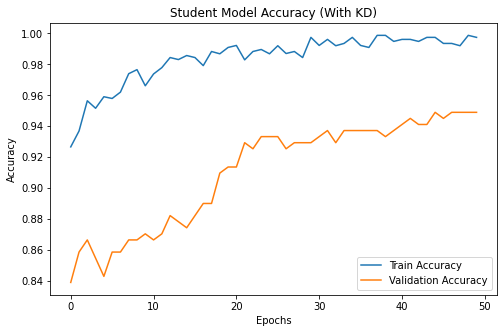

<Figure size 864x720 with 0 Axes>

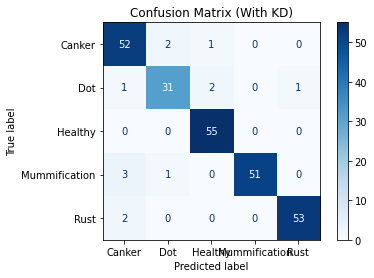

In [20]:
# Training loop for Knowledge Distillation
epochs =50
train_acc_kd = []
val_acc_kd = []
train_loss_kd = []
val_loss_kd = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_loss = 0
    total_train_acc = 0

    for batch, (x_batch_train, y_batch_train) in enumerate(train_data):
        # Get the soft labels from the teacher model (Xception)
        teacher_predictions = teacher_model.predict(x_batch_train)

        # Train the student model using both hard and soft labels
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = distillation_loss(y_batch_train, student_predictions, teacher_predictions)

        # Apply gradients
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Accumulate training loss (use the mean of the batch loss to avoid shape mismatch)
        total_train_loss += tf.reduce_mean(loss_value).numpy()

        # Calculate and accumulate accuracy for the current batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy

    # Store the average accuracy and loss for this epoch
    avg_train_loss = total_train_loss / len(train_data)
    avg_train_acc = total_train_acc / len(train_data)

    train_loss_kd.append(avg_train_loss)
    train_acc_kd.append(avg_train_acc)

    # Evaluate on validation data
    val_loss_epoch, val_acc_epoch = student_model.evaluate(valid_data, verbose=0)
    val_loss_kd.append(val_loss_epoch)
    val_acc_kd.append(val_acc_epoch)

# Final evaluation after KD
student_kd_accuracy = student_model.evaluate(valid_data)
print(f"Final Student Model Accuracy (with KD): {student_kd_accuracy[1] * 100:.2f}%")

# Plot Accuracy Graphs
def plot_accuracy_graph(train_acc, val_acc, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Call the function to plot accuracy graph for Knowledge Distillation
plot_accuracy_graph(train_acc_kd, val_acc_kd, "Student Model Accuracy (With KD)")

# Plot Confusion Matrix (With KD)
def plot_confusion_matrix_with_kd(model, test_data, class_names, title):
    # Get true labels and predicted labels
    true_labels = np.concatenate([y for x, y in test_data], axis=0)
    predictions = model.predict(test_data)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(true_labels, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.show()

# Call the function to plot confusion matrix for KD
plot_confusion_matrix_with_kd(student_model, valid_data, class_names, "Confusion Matrix (With KD)")


# InceptionV3

In [25]:
teacher_model = tf.keras.models.load_model('/kaggle/input/inceptionv3/inceptionv3_advanced_model.h5')
teacher_loss, teacher_accuracy = teacher_model.evaluate(valid_data, verbose=1)

# Print the accuracy
print(f"Teacher Model Accuracy: {teacher_accuracy * 100:.2f}%")


8/8 [==============================] - 2s 76ms/step - loss: 0.1116 - accuracy: 0.9804
Teacher Model Accuracy: 98.04%


# CNN

8/8 [==============================] - 0s 19ms/step - loss: 0.6038 - accuracy: 0.7608
Loaded Student Model Accuracy: 76.08%
Epoch 1/50
Epoch 1 - Train Accuracy: 77.18%, Validation Accuracy: 77.01%
Epoch 2/50
Epoch 2 - Train Accuracy: 76.25%, Validation Accuracy: 79.69%
Epoch 3/50
Epoch 3 - Train Accuracy: 78.50%, Validation Accuracy: 75.10%
Epoch 4/50
Epoch 4 - Train Accuracy: 76.82%, Validation Accuracy: 74.33%
Epoch 5/50
Epoch 5 - Train Accuracy: 78.50%, Validation Accuracy: 75.10%
Epoch 6/50
Epoch 6 - Train Accuracy: 79.04%, Validation Accuracy: 73.95%
Epoch 7/50
Epoch 7 - Train Accuracy: 79.43%, Validation Accuracy: 77.39%
Epoch 8/50
Epoch 8 - Train Accuracy: 80.06%, Validation Accuracy: 77.39%
Epoch 9/50
Epoch 9 - Train Accuracy: 78.24%, Validation Accuracy: 80.84%
Epoch 10/50
Epoch 10 - Train Accuracy: 77.40%, Validation Accuracy: 75.48%
Epoch 11/50
Epoch 11 - Train Accuracy: 78.39%, Validation Accuracy: 70.11%
Epoch 12/50
Epoch 12 - Train Accuracy: 80.19%, Validation Accuracy: 7

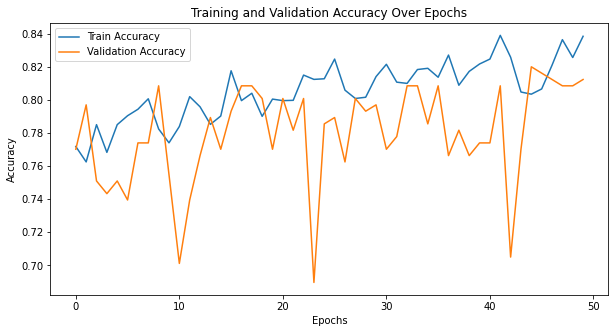

In [26]:

student_model = tf.keras.models.load_model('/kaggle/input/student-models/cnn_student_model.h5')
student_accuracy = student_model.evaluate(valid_data)
print(f"Loaded Student Model Accuracy: {student_accuracy[1] * 100:.2f}%")



import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Variables to track training and validation accuracy and loss
train_acc = []
val_acc = []

# Compile the student model
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Training loop for knowledge distillation
epochs =50
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    
    total_train_acc = 0
    num_batches = 0
    
    for batch, (x_batch_train, y_batch_train) in enumerate(train_data):
        # Get the soft labels from the teacher (Xception model)
        teacher_predictions = teacher_model.predict(x_batch_train)

        # Train the student model using both soft and hard labels
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = distillation_loss(y_batch_train, student_predictions, teacher_predictions)

        # Apply gradients to update the model's weights
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Calculate training accuracy for the batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Calculate average training accuracy for the epoch
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Evaluate the student model on the validation set
    val_loss, val_accuracy = student_model.evaluate(test_data, verbose=0)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Step 2: Plot Accuracy Graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Plot accuracy
plot_accuracy(train_acc, val_acc)


# Mobailenet Student

8/8 [==============================] - 1s 45ms/step - loss: 1.6495 - accuracy: 0.8000
Loaded Student Model Accuracy: 80.00%
Epoch 1/50
Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50
8/8 [==============================] - 0s 40ms/step - loss: 1.2355 - accuracy: 0.9451
Final Student Model Accuracy (with KD): 94.51%


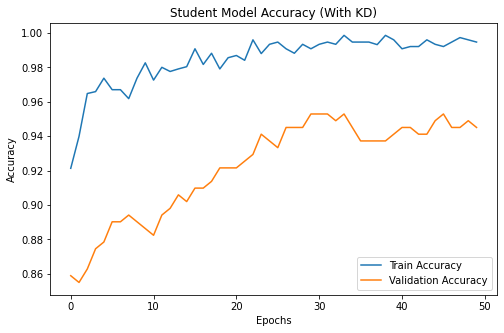

<Figure size 864x720 with 0 Axes>

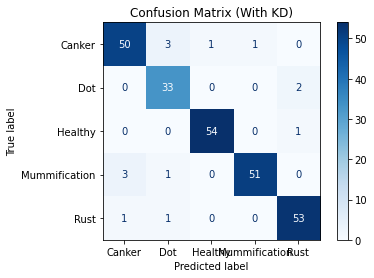

In [27]:
# Corrected code to load the student model
student_model = tf.keras.models.load_model('/kaggle/input/mobailenet1/mobailenet.h5')
student_accuracy = student_model.evaluate(valid_data)
print(f"Loaded Student Model Accuracy: {student_accuracy[1] * 100:.2f}%")



# Training loop for Knowledge Distillation
epochs =50
train_acc_kd = []
val_acc_kd = []
train_loss_kd = []
val_loss_kd = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_loss = 0
    total_train_acc = 0

    for batch, (x_batch_train, y_batch_train) in enumerate(train_data):
        # Get the soft labels from the teacher model (Xception)
        teacher_predictions = teacher_model.predict(x_batch_train)

        # Train the student model using both hard and soft labels
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = distillation_loss(y_batch_train, student_predictions, teacher_predictions)

        # Apply gradients
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Accumulate training loss (use the mean of the batch loss to avoid shape mismatch)
        total_train_loss += tf.reduce_mean(loss_value).numpy()

        # Calculate and accumulate accuracy for the current batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy

    # Store the average accuracy and loss for this epoch
    avg_train_loss = total_train_loss / len(train_data)
    avg_train_acc = total_train_acc / len(train_data)

    train_loss_kd.append(avg_train_loss)
    train_acc_kd.append(avg_train_acc)

    # Evaluate on validation data
    val_loss_epoch, val_acc_epoch = student_model.evaluate(valid_data, verbose=0)
    val_loss_kd.append(val_loss_epoch)
    val_acc_kd.append(val_acc_epoch)

# Final evaluation after KD
student_kd_accuracy = student_model.evaluate(valid_data)
print(f"Final Student Model Accuracy (with KD): {student_kd_accuracy[1] * 100:.2f}%")

# Plot Accuracy Graphs
def plot_accuracy_graph(train_acc, val_acc, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Call the function to plot accuracy graph for Knowledge Distillation
plot_accuracy_graph(train_acc_kd, val_acc_kd, "Student Model Accuracy (With KD)")

# Plot Confusion Matrix (With KD)
def plot_confusion_matrix_with_kd(model, test_data, class_names, title):
    # Get true labels and predicted labels
    true_labels = np.concatenate([y for x, y in test_data], axis=0)
    predictions = model.predict(test_data)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(true_labels, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.show()

# Call the function to plot confusion matrix for KD
plot_confusion_matrix_with_kd(student_model, valid_data, class_names, "Confusion Matrix (With KD)")


# Inceptionres

In [35]:
teacher_model = tf.keras.models.load_model('/kaggle/working/inception_resnet_advanced_model.h5')
teacher_loss, teacher_accuracy = teacher_model.evaluate(valid_data, verbose=1)

# Print the accuracy
print(f"Teacher Model Accuracy: {teacher_accuracy * 100:.2f}%")


8/8 [==============================] - 5s 173ms/step - loss: 0.0727 - accuracy: 0.9725
Teacher Model Accuracy: 97.25%


# CNN Student

8/8 [==============================] - 0s 17ms/step - loss: 0.6038 - accuracy: 0.7608
Loaded Student Model Accuracy: 76.08%
Epoch 1/50
Epoch 1 - Train Accuracy: 74.74%, Validation Accuracy: 75.48%
Epoch 2/50
Epoch 2 - Train Accuracy: 78.35%, Validation Accuracy: 75.48%
Epoch 3/50
Epoch 3 - Train Accuracy: 78.98%, Validation Accuracy: 78.54%
Epoch 4/50
Epoch 4 - Train Accuracy: 77.47%, Validation Accuracy: 77.01%
Epoch 5/50
Epoch 5 - Train Accuracy: 79.30%, Validation Accuracy: 79.31%
Epoch 6/50
Epoch 6 - Train Accuracy: 78.79%, Validation Accuracy: 74.33%
Epoch 7/50
Epoch 7 - Train Accuracy: 79.58%, Validation Accuracy: 79.31%
Epoch 8/50
Epoch 8 - Train Accuracy: 80.47%, Validation Accuracy: 78.54%
Epoch 9/50
Epoch 9 - Train Accuracy: 78.31%, Validation Accuracy: 79.31%
Epoch 10/50
Epoch 10 - Train Accuracy: 80.34%, Validation Accuracy: 72.41%
Epoch 11/50
Epoch 11 - Train Accuracy: 78.50%, Validation Accuracy: 75.10%
Epoch 12/50
Epoch 12 - Train Accuracy: 78.78%, Validation Accuracy: 7

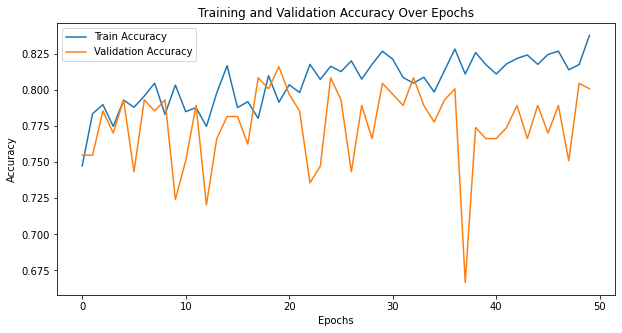

In [36]:

student_model = tf.keras.models.load_model('/kaggle/input/student-models/cnn_student_model.h5')
student_accuracy = student_model.evaluate(valid_data)
print(f"Loaded Student Model Accuracy: {student_accuracy[1] * 100:.2f}%")



import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Variables to track training and validation accuracy and loss
train_acc = []
val_acc = []

# Compile the student model
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Training loop for knowledge distillation
epochs =50
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    
    total_train_acc = 0
    num_batches = 0
    
    for batch, (x_batch_train, y_batch_train) in enumerate(train_data):
        # Get the soft labels from the teacher (Xception model)
        teacher_predictions = teacher_model.predict(x_batch_train)

        # Train the student model using both soft and hard labels
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = distillation_loss(y_batch_train, student_predictions, teacher_predictions)

        # Apply gradients to update the model's weights
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Calculate training accuracy for the batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Calculate average training accuracy for the epoch
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Evaluate the student model on the validation set
    val_loss, val_accuracy = student_model.evaluate(test_data, verbose=0)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Step 2: Plot Accuracy Graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Plot accuracy
plot_accuracy(train_acc, val_acc)


# Mobailenet student

8/8 [==============================] - 1s 46ms/step - loss: 1.6495 - accuracy: 0.8000
Loaded Student Model Accuracy: 80.00%
Epoch 1/50
Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50
8/8 [==============================] - 0s 40ms/step - loss: 1.2328 - accuracy: 0.9569
Final Student Model Accuracy (with KD): 95.69%


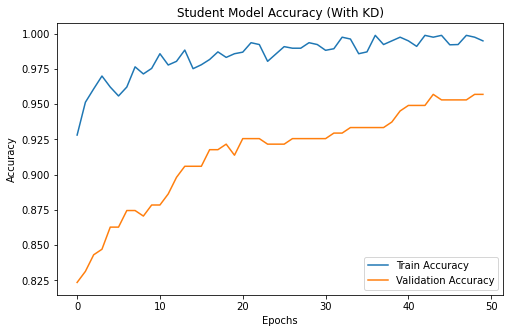

<Figure size 864x720 with 0 Axes>

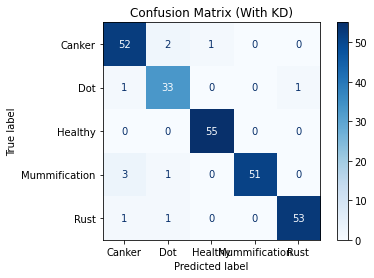

In [37]:
# Corrected code to load the student model
student_model = tf.keras.models.load_model('/kaggle/input/mobailenet1/mobailenet.h5')
student_accuracy = student_model.evaluate(valid_data)
print(f"Loaded Student Model Accuracy: {student_accuracy[1] * 100:.2f}%")



# Training loop for Knowledge Distillation
epochs =50
train_acc_kd = []
val_acc_kd = []
train_loss_kd = []
val_loss_kd = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_loss = 0
    total_train_acc = 0

    for batch, (x_batch_train, y_batch_train) in enumerate(train_data):
        # Get the soft labels from the teacher model (Xception)
        teacher_predictions = teacher_model.predict(x_batch_train)

        # Train the student model using both hard and soft labels
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = distillation_loss(y_batch_train, student_predictions, teacher_predictions)

        # Apply gradients
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Accumulate training loss (use the mean of the batch loss to avoid shape mismatch)
        total_train_loss += tf.reduce_mean(loss_value).numpy()

        # Calculate and accumulate accuracy for the current batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy

    # Store the average accuracy and loss for this epoch
    avg_train_loss = total_train_loss / len(train_data)
    avg_train_acc = total_train_acc / len(train_data)

    train_loss_kd.append(avg_train_loss)
    train_acc_kd.append(avg_train_acc)

    # Evaluate on validation data
    val_loss_epoch, val_acc_epoch = student_model.evaluate(valid_data, verbose=0)
    val_loss_kd.append(val_loss_epoch)
    val_acc_kd.append(val_acc_epoch)

# Final evaluation after KD
student_kd_accuracy = student_model.evaluate(valid_data)
print(f"Final Student Model Accuracy (with KD): {student_kd_accuracy[1] * 100:.2f}%")

# Plot Accuracy Graphs
def plot_accuracy_graph(train_acc, val_acc, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Call the function to plot accuracy graph for Knowledge Distillation
plot_accuracy_graph(train_acc_kd, val_acc_kd, "Student Model Accuracy (With KD)")

# Plot Confusion Matrix (With KD)
def plot_confusion_matrix_with_kd(model, test_data, class_names, title):
    # Get true labels and predicted labels
    true_labels = np.concatenate([y for x, y in test_data], axis=0)
    predictions = model.predict(test_data)
    predicted_labels = np.argmax(predictions, axis=1)
    true_labels = np.argmax(true_labels, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Plot confusion matrix
    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d')
    plt.title(title)
    plt.show()

# Call the function to plot confusion matrix for KD
plot_confusion_matrix_with_kd(student_model, valid_data, class_names, "Confusion Matrix (With KD)")


# Multi

# CNN

8/8 [==============================] - 0s 19ms/step - loss: 0.6038 - accuracy: 0.7608
Loaded Student Model Accuracy: 76.08%
Epoch 1/50
Epoch 1 - Train Accuracy: 75.48%, Validation Accuracy: 76.63%
Epoch 2/50
Epoch 2 - Train Accuracy: 77.05%, Validation Accuracy: 75.48%
Epoch 3/50
Epoch 3 - Train Accuracy: 77.46%, Validation Accuracy: 73.18%
Epoch 4/50
Epoch 4 - Train Accuracy: 78.61%, Validation Accuracy: 75.10%
Epoch 5/50
Epoch 5 - Train Accuracy: 79.28%, Validation Accuracy: 79.31%
Epoch 6/50
Epoch 6 - Train Accuracy: 79.43%, Validation Accuracy: 80.46%
Epoch 7/50
Epoch 7 - Train Accuracy: 77.99%, Validation Accuracy: 78.54%
Epoch 8/50
Epoch 8 - Train Accuracy: 79.71%, Validation Accuracy: 80.84%
Epoch 9/50
Epoch 9 - Train Accuracy: 79.17%, Validation Accuracy: 73.56%
Epoch 10/50
Epoch 10 - Train Accuracy: 79.20%, Validation Accuracy: 79.69%
Epoch 11/50
Epoch 11 - Train Accuracy: 79.24%, Validation Accuracy: 77.39%
Epoch 12/50
Epoch 12 - Train Accuracy: 80.54%, Validation Accuracy: 7

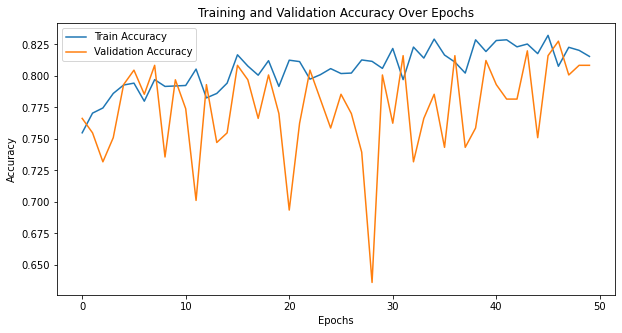

In [39]:

student_model = tf.keras.models.load_model('/kaggle/input/student-models/cnn_student_model.h5')
student_accuracy = student_model.evaluate(valid_data)
print(f"Loaded Student Model Accuracy: {student_accuracy[1] * 100:.2f}%")


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
import numpy as np

# Assuming the teachers are already loaded
teacher_model_1 = tf.keras.models.load_model("/kaggle/input/xception3/xception_teacher_model (1).h5")
teacher_model_2 = tf.keras.models.load_model("/kaggle/input/inceptionres1/inception_resnet_advanced_model (1).h5")

# Compile the student model
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
                      loss='categorical_crossentropy', metrics=['accuracy'])

# Variables to track training and validation accuracy and loss
train_acc = []
val_acc = []

# Custom multi-teacher distillation loss function
def distillation_loss(y_true, y_pred_student, teacher_preds):
    teacher_preds_1, teacher_preds_2 = teacher_preds
    
    # Hyperparameters for weighting losses
    alpha = 0.5  # Controls weight between hard and soft labels
    T = 3.0      # Temperature for distillation
    
    # Soft loss (KLD between teacher soft targets and student predictions)
    soft_loss_1 = tf.keras.losses.KLDivergence()(tf.nn.softmax(teacher_preds_1 / T), tf.nn.softmax(y_pred_student / T))
    soft_loss_2 = tf.keras.losses.KLDivergence()(tf.nn.softmax(teacher_preds_2 / T), tf.nn.softmax(y_pred_student / T))
    
    # Average the soft losses from both teachers
    soft_loss = (soft_loss_1 + soft_loss_2) / 2.0
    
    # Hard loss (cross-entropy with true labels)
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred_student)
    
    # Combined loss
    total_loss = alpha * hard_loss + (1 - alpha) * soft_loss * (T * T)
    return total_loss

# Training loop for multi-teacher knowledge distillation
epochs = 50
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    
    total_train_acc = 0
    num_batches = 0
    
    for batch, (x_batch_train, y_batch_train) in enumerate(train_data):
        # Get soft labels from both teacher models
        teacher_preds_1 = teacher_model_1.predict(x_batch_train)
        teacher_preds_2 = teacher_model_2.predict(x_batch_train)

        # Train the student model using the combined distillation loss
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = distillation_loss(y_batch_train, student_predictions, (teacher_preds_1, teacher_preds_2))

        # Apply gradients to update the model's weights
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Calculate training accuracy for the batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Calculate average training accuracy for the epoch
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Evaluate the student model on the validation set
    val_loss, val_accuracy = student_model.evaluate(test_data, verbose=0)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Step 2: Plot Accuracy Graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Plot accuracy
plot_accuracy(train_acc, val_acc)


Epoch 1/50
Epoch 1 - Train Accuracy: 77.01%, Validation Accuracy: 77.01%
Epoch 2/50
Epoch 2 - Train Accuracy: 77.64%, Validation Accuracy: 78.54%
Epoch 3/50
Epoch 3 - Train Accuracy: 76.10%, Validation Accuracy: 78.93%
Epoch 4/50
Epoch 4 - Train Accuracy: 78.42%, Validation Accuracy: 77.78%
Epoch 5/50
Epoch 5 - Train Accuracy: 77.53%, Validation Accuracy: 77.39%
Epoch 6/50
Epoch 6 - Train Accuracy: 78.81%, Validation Accuracy: 76.25%
Epoch 7/50
Epoch 7 - Train Accuracy: 78.16%, Validation Accuracy: 79.31%
Epoch 8/50
Epoch 8 - Train Accuracy: 77.90%, Validation Accuracy: 82.76%
Epoch 9/50
Epoch 9 - Train Accuracy: 77.64%, Validation Accuracy: 79.69%
Epoch 10/50
Epoch 10 - Train Accuracy: 78.03%, Validation Accuracy: 77.39%
Epoch 11/50
Epoch 11 - Train Accuracy: 79.07%, Validation Accuracy: 78.93%
Epoch 12/50
Epoch 12 - Train Accuracy: 79.07%, Validation Accuracy: 77.78%
Epoch 13/50
Epoch 13 - Train Accuracy: 79.09%, Validation Accuracy: 79.31%
Epoch 14/50
Epoch 14 - Train Accuracy: 80.6

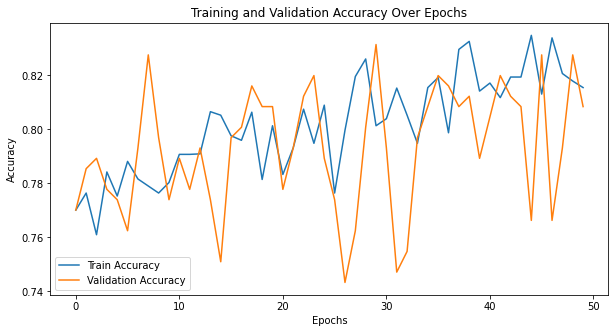

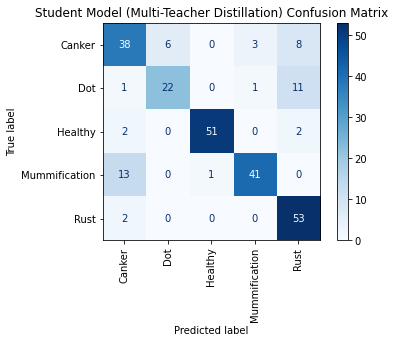

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load teacher models
teacher_model_1 = tf.keras.models.load_model("/kaggle/input/xception3/xception_teacher_model (1).h5")
teacher_model_2 = tf.keras.models.load_model("/kaggle/input/inceptionres1/inception_resnet_advanced_model (1).h5")

# Load student model
student_model = tf.keras.models.load_model("/kaggle/input/student-models/cnn_student_model.h5")

# Distillation parameters
alpha = 0.4  # Weight for the true labels in the distillation loss
T = 5.0      # Temperature for softening the teacher predictions

# Teacher model weights for weighted average of predictions
weight_1 = 0.6
weight_2 = 0.4

def distillation_loss(y_true, y_pred_student, teacher_preds):
    teacher_preds_1, teacher_preds_2 = teacher_preds

    # Combine teacher predictions using specified weights
    combined_teacher_preds = weight_1 * teacher_preds_1 + weight_2 * teacher_preds_2

    # Soft loss (Kullback-Leibler Divergence with temperature scaling)
    soft_loss = tf.keras.losses.KLDivergence()(
        tf.nn.softmax(combined_teacher_preds / T), tf.nn.softmax(y_pred_student / T)
    )

    # Hard loss (categorical cross-entropy with true labels)
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred_student)

    # Weighted sum of hard and soft losses
    total_loss = alpha * hard_loss + (1 - alpha) * soft_loss * (T * T)
    return total_loss

# Track training and validation accuracy
train_acc = []
val_acc = []

# Compile the student model with both loss and accuracy metrics
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Number of epochs for training
epochs = 50

# Training loop
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_acc = 0
    num_batches = 0

    for x_batch_train, y_batch_train in train_data:
        # Teacher predictions
        teacher_preds_1 = teacher_model_1.predict(x_batch_train)
        teacher_preds_2 = teacher_model_2.predict(x_batch_train)

        # Train the student model
        with tf.GradientTape() as tape:
            # Student predictions
            student_predictions = student_model(x_batch_train, training=True)
            
            # Calculate distillation loss
            loss_value = distillation_loss(y_batch_train, student_predictions, (teacher_preds_1, teacher_preds_2))

        # Apply gradients to student model
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Calculate accuracy for this batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Average training accuracy for the epoch
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Evaluate on validation set
    val_loss, val_accuracy = student_model.evaluate(test_data, verbose=0)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Save the final trained student model
student_model.save("/kaggle/working/final_student_model.h5")

# Plot the accuracy graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc, val_acc)

# Plot confusion matrix for the student model
def plot_confusion_matrix(model, test_data, class_names, title):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_data:
        predictions = model.predict(x_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(y_batch.numpy(), axis=1)

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(title)
    plt.show()

plot_confusion_matrix(student_model, valid_data, class_names, "Student Model (Multi-Teacher Distillation) Confusion Matrix")


Epoch 1/50
Epoch 1 - Train Accuracy: 82.63%, Validation Accuracy: 76.08%
Epoch 2/50
Epoch 2 - Train Accuracy: 81.88%, Validation Accuracy: 77.65%
Epoch 3/50
Epoch 3 - Train Accuracy: 83.30%, Validation Accuracy: 83.14%
Epoch 4/50
Epoch 4 - Train Accuracy: 83.30%, Validation Accuracy: 80.78%
Epoch 5/50
Epoch 5 - Train Accuracy: 82.51%, Validation Accuracy: 80.00%
Epoch 6/50
Epoch 6 - Train Accuracy: 83.05%, Validation Accuracy: 81.18%
Epoch 7/50
Epoch 7 - Train Accuracy: 83.44%, Validation Accuracy: 79.22%
Epoch 8/50
Epoch 8 - Train Accuracy: 84.10%, Validation Accuracy: 78.82%
Epoch 9/50
Epoch 9 - Train Accuracy: 83.71%, Validation Accuracy: 80.00%
Epoch 10/50
Epoch 10 - Train Accuracy: 82.81%, Validation Accuracy: 78.82%
Epoch 11/50
Epoch 11 - Train Accuracy: 81.73%, Validation Accuracy: 79.22%
Epoch 12/50
Epoch 12 - Train Accuracy: 82.78%, Validation Accuracy: 78.82%
Epoch 13/50
Epoch 13 - Train Accuracy: 83.84%, Validation Accuracy: 77.65%
Epoch 14/50
Epoch 14 - Train Accuracy: 84.2

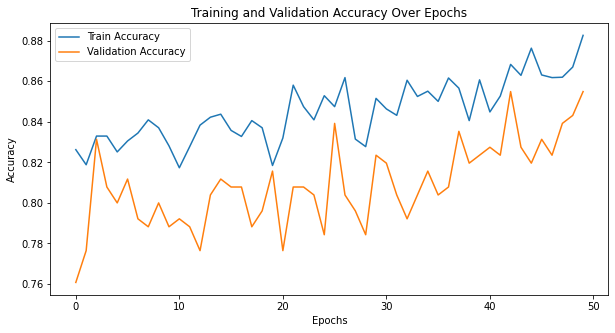

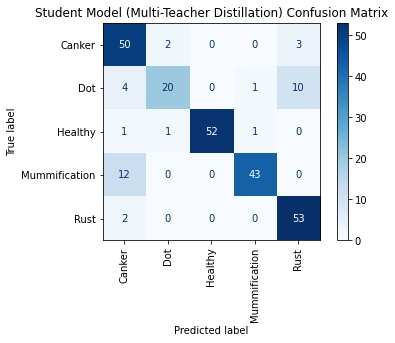

In [15]:
import tensorflow as tf
import numpy as np

# Distillation parameters
alpha = 0.7      # Increase hard label importance
T = 2.0          # Lower temperature
weight_1 = 0.7   # Adjust weights if teacher model 1 is better
weight_2 = 0.3

train_acc = []
val_acc = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_acc = 0
    num_batches = 0

    for x_batch_train, y_batch_train in train_data:
       # Teacher predictions with noise injection
        teacher_preds_1 = teacher_model_1.predict(x_batch_train)
        teacher_preds_1 += np.random.normal(0, 0.01, teacher_preds_1.shape)
        
        teacher_preds_2 = teacher_model_2.predict(x_batch_train)
        teacher_preds_2 += np.random.normal(0, 0.01, teacher_preds_2.shape)
        # Training student model
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            
            # Hard loss with label smoothing
            hard_loss = tf.keras.losses.categorical_crossentropy(y_batch_train, student_predictions, label_smoothing=0.1)
            
            # Soft loss
            combined_teacher_preds = weight_1 * teacher_preds_1 + weight_2 * teacher_preds_2
            soft_loss = tf.keras.losses.KLDivergence()(
                tf.nn.softmax(combined_teacher_preds / T), tf.nn.softmax(student_predictions / T)
            )
            
            # Entropy regularization
            entropy_reg = -tf.reduce_sum(tf.nn.softmax(student_predictions) * tf.math.log(tf.nn.softmax(student_predictions) + 1e-9), axis=-1)
            entropy_loss = 0.01 * tf.reduce_mean(entropy_reg)
            
            # Combined distillation loss
            loss_value = alpha * hard_loss + (1 - alpha) * soft_loss * (T * T) + entropy_loss

        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Batch accuracy
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Epoch accuracy
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Validation evaluation
    val_metrics = student_model.evaluate(valid_data, verbose=0)
    val_acc.append(val_metrics[1])

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_metrics[1] * 100:.2f}%")


# Plot the accuracy graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc, val_acc)

# Plot confusion matrix for the student model
def plot_confusion_matrix(model, test_data, class_names, title):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_data:
        predictions = model.predict(x_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(y_batch.numpy(), axis=1)

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(title)
    plt.show()

plot_confusion_matrix(student_model, valid_data, class_names, "Student Model (Multi-Teacher Distillation) Confusion Matrix")

In [19]:
# Evaluate the final model on the validation set
final_loss, final_accuracy = student_model.evaluate(valid_data, verbose=0)
print(f"Final Student Model Accuracy on Validation Set: {final_accuracy * 100:.2f}%")

# If you have a test set, you can evaluate there as well
final_test_loss, final_test_accuracy = student_model.evaluate(test_data, verbose=0)
print(f"Final Student Model Accuracy on Test Set: {final_test_accuracy * 100:.2f}%")


Final Student Model Accuracy on Validation Set: 85.49%
Final Student Model Accuracy on Test Set: 84.67%


In [18]:
student_model.save("Multi_CNN_student_model.h5")


# Self


Epoch 1/50
Epoch 1 - Train Accuracy: 87.20%, Validation Accuracy: 83.14%
Epoch 2/50
Epoch 2 - Train Accuracy: 85.73%, Validation Accuracy: 84.29%
Epoch 3/50
Epoch 3 - Train Accuracy: 86.51%, Validation Accuracy: 83.52%
Epoch 4/50
Epoch 4 - Train Accuracy: 86.74%, Validation Accuracy: 82.38%
Epoch 5/50
Epoch 5 - Train Accuracy: 88.39%, Validation Accuracy: 81.23%
Epoch 6/50
Epoch 6 - Train Accuracy: 87.31%, Validation Accuracy: 83.14%
Epoch 7/50
Epoch 7 - Train Accuracy: 89.01%, Validation Accuracy: 83.91%
Epoch 8/50
Epoch 8 - Train Accuracy: 85.58%, Validation Accuracy: 83.52%
Epoch 9/50
Epoch 9 - Train Accuracy: 88.34%, Validation Accuracy: 83.14%
Epoch 10/50
Epoch 10 - Train Accuracy: 88.62%, Validation Accuracy: 85.06%
Epoch 11/50
Epoch 11 - Train Accuracy: 86.64%, Validation Accuracy: 85.82%
Epoch 12/50
Epoch 12 - Train Accuracy: 87.82%, Validation Accuracy: 83.91%
Epoch 13/50
Epoch 13 - Train Accuracy: 87.03%, Validation Accuracy: 83.14%
Epoch 14/50
Epoch 14 - Train Accuracy: 86.9

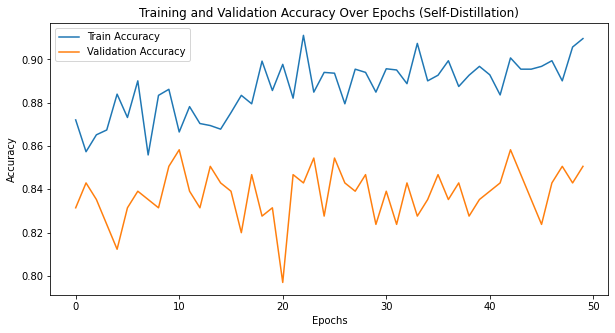

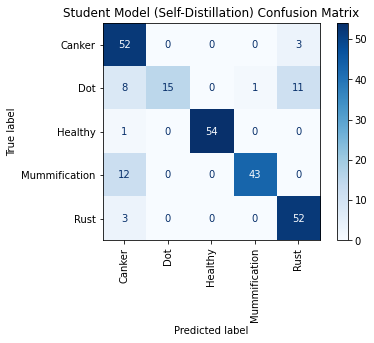

In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load your existing student CNN model
student_model = tf.keras.models.load_model("/kaggle/working/Multi_CNN_student_model.h5")

# Parameters for self-distillation
alpha = 0.7  # Weight for the true labels in the distillation loss
T = 2.0      # Temperature for softening the predictions (increase for smoother self-labels)

# Distillation loss function for self-distillation
def self_distillation_loss(y_true, y_pred_student):
    # Softened student predictions (self-generated teacher predictions)
    soft_teacher_preds = tf.nn.softmax(y_pred_student / T)

    # Soft loss (Kullback-Leibler Divergence with temperature scaling)
    soft_loss = tf.keras.losses.KLDivergence()(
        soft_teacher_preds, tf.nn.softmax(y_pred_student / T)
    )

    # Hard loss (categorical cross-entropy with true labels)
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred_student)

    # Weighted sum of hard and soft losses
    total_loss = alpha * hard_loss + (1 - alpha) * soft_loss * (T * T)
    return total_loss

# Track training and validation accuracy
train_acc = []
val_acc = []

# Compile the student model with optimizer (loss will be handled in the loop)
# Ensure the student model is compiled with accuracy as a metric
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), metrics=['accuracy'])
epochs = 50
# Training loop with fixed evaluation step
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_acc = 0
    num_batches = 0

    for x_batch_train, y_batch_train in train_data:
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            loss_value = self_distillation_loss(y_batch_train, student_predictions)

        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Update this line to handle single or multiple outputs from evaluate
    eval_results = student_model.evaluate(test_data, verbose=0)
    val_loss, val_accuracy = eval_results if isinstance(eval_results, (list, tuple)) else (eval_results, None)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Save the self-distilled student model
student_model.save("/kaggle/working/self_distilled_student_model.h5")

# Plot accuracy graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs (Self-Distillation)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

# Plot the accuracy graph
plot_accuracy(train_acc, val_acc)

# Plot confusion matrix
def plot_confusion_matrix(model, test_data, class_names, title):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_data:
        predictions = model.predict(x_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(y_batch.numpy(), axis=1)

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(title)
    plt.show()

# Plot confusion matrix for the self-distilled student model
plot_confusion_matrix(student_model, valid_data, class_names, "Student Model (Self-Distillation) Confusion Matrix")


# MobaileNET

Epoch 1/50
Epoch 1 - Train Accuracy: 91.48%, Validation Accuracy: 83.91%
Epoch 2/50
Epoch 2 - Train Accuracy: 95.01%, Validation Accuracy: 79.31%
Epoch 3/50
Epoch 3 - Train Accuracy: 96.04%, Validation Accuracy: 77.01%
Epoch 4/50
Epoch 4 - Train Accuracy: 97.49%, Validation Accuracy: 79.31%
Epoch 5/50
Epoch 5 - Train Accuracy: 96.97%, Validation Accuracy: 77.78%
Epoch 6/50
Epoch 6 - Train Accuracy: 97.51%, Validation Accuracy: 77.78%
Epoch 7/50
Epoch 7 - Train Accuracy: 98.57%, Validation Accuracy: 81.23%
Epoch 8/50
Epoch 8 - Train Accuracy: 98.42%, Validation Accuracy: 80.46%
Epoch 9/50
Epoch 9 - Train Accuracy: 98.96%, Validation Accuracy: 81.99%
Epoch 10/50
Epoch 10 - Train Accuracy: 98.83%, Validation Accuracy: 81.99%
Epoch 11/50
Epoch 11 - Train Accuracy: 98.83%, Validation Accuracy: 80.46%
Epoch 12/50
Epoch 12 - Train Accuracy: 98.29%, Validation Accuracy: 82.38%
Epoch 13/50
Epoch 13 - Train Accuracy: 98.96%, Validation Accuracy: 84.67%
Epoch 14/50
Epoch 14 - Train Accuracy: 98.9

/opt/conda/lib/python3.7/site-packages/keras/utils/generic_utils.py:497: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  category=CustomMaskWarning)


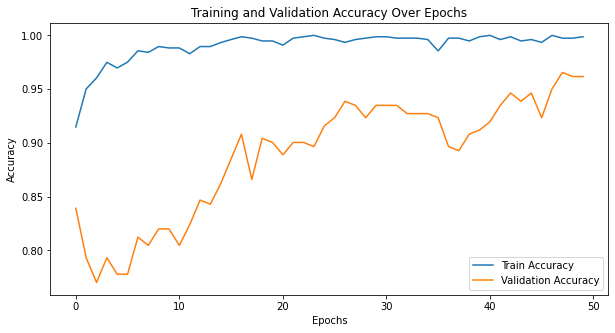

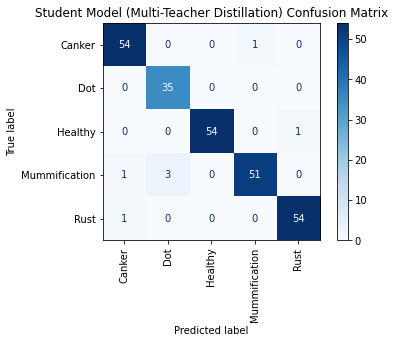

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load teacher models
teacher_model_1 = tf.keras.models.load_model("/kaggle/input/xception3/xception_teacher_model (1).h5")
teacher_model_2 = tf.keras.models.load_model("/kaggle/input/inceptionres1/inception_resnet_advanced_model (1).h5")

# Load student model
student_model = tf.keras.models.load_model("/kaggle/input/mobailenet1/mobailenet.h5")

# Distillation parameters
alpha = 0.4  # Weight for the true labels in the distillation loss
T = 5.0      # Temperature for softening the teacher predictions

# Teacher model weights for weighted average of predictions
weight_1 = 0.6
weight_2 = 0.4

def distillation_loss(y_true, y_pred_student, teacher_preds):
    teacher_preds_1, teacher_preds_2 = teacher_preds

    # Combine teacher predictions using specified weights
    combined_teacher_preds = weight_1 * teacher_preds_1 + weight_2 * teacher_preds_2

    # Soft loss (Kullback-Leibler Divergence with temperature scaling)
    soft_loss = tf.keras.losses.KLDivergence()(
        tf.nn.softmax(combined_teacher_preds / T), tf.nn.softmax(y_pred_student / T)
    )

    # Hard loss (categorical cross-entropy with true labels)
    hard_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred_student)

    # Weighted sum of hard and soft losses
    total_loss = alpha * hard_loss + (1 - alpha) * soft_loss * (T * T)
    return total_loss

# Track training and validation accuracy
train_acc = []
val_acc = []

# Compile the student model with both loss and accuracy metrics
student_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

# Number of epochs for training
epochs = 50

# Training loop
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_acc = 0
    num_batches = 0

    for x_batch_train, y_batch_train in train_data:
        # Teacher predictions
        teacher_preds_1 = teacher_model_1.predict(x_batch_train)
        teacher_preds_2 = teacher_model_2.predict(x_batch_train)

        # Train the student model
        with tf.GradientTape() as tape:
            # Student predictions
            student_predictions = student_model(x_batch_train, training=True)
            
            # Calculate distillation loss
            loss_value = distillation_loss(y_batch_train, student_predictions, (teacher_preds_1, teacher_preds_2))

        # Apply gradients to student model
        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Calculate accuracy for this batch
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Average training accuracy for the epoch
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Evaluate on validation set
    val_loss, val_accuracy = student_model.evaluate(test_data, verbose=0)
    val_acc.append(val_accuracy)

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_accuracy * 100:.2f}%")

# Save the final trained student model
student_model.save("/kaggle/working/final_student_model.h5")

# Plot the accuracy graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc, val_acc)

# Plot confusion matrix for the student model
def plot_confusion_matrix(model, test_data, class_names, title):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_data:
        predictions = model.predict(x_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(y_batch.numpy(), axis=1)

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(title)
    plt.show()

plot_confusion_matrix(student_model, valid_data, class_names, "Student Model (Multi-Teacher Distillation) Confusion Matrix")


Epoch 1/80
Epoch 1 - Train Accuracy: 98.31%, Validation Accuracy: 90.98%
Epoch 2/80
Epoch 2 - Train Accuracy: 98.94%, Validation Accuracy: 93.33%
Epoch 3/80
Epoch 3 - Train Accuracy: 99.35%, Validation Accuracy: 92.55%
Epoch 4/80
Epoch 4 - Train Accuracy: 99.07%, Validation Accuracy: 89.02%
Epoch 5/80
Epoch 5 - Train Accuracy: 99.87%, Validation Accuracy: 94.51%
Epoch 6/80
Epoch 6 - Train Accuracy: 99.87%, Validation Accuracy: 93.73%
Epoch 7/80
Epoch 7 - Train Accuracy: 100.00%, Validation Accuracy: 94.90%
Epoch 8/80
Epoch 8 - Train Accuracy: 99.87%, Validation Accuracy: 94.12%
Epoch 9/80
Epoch 9 - Train Accuracy: 99.87%, Validation Accuracy: 94.51%
Epoch 10/80
Epoch 10 - Train Accuracy: 99.87%, Validation Accuracy: 94.90%
Epoch 11/80
Epoch 11 - Train Accuracy: 99.87%, Validation Accuracy: 93.73%
Epoch 12/80
Epoch 12 - Train Accuracy: 99.74%, Validation Accuracy: 94.51%
Epoch 13/80
Epoch 13 - Train Accuracy: 100.00%, Validation Accuracy: 95.29%
Epoch 14/80
Epoch 14 - Train Accuracy: 99

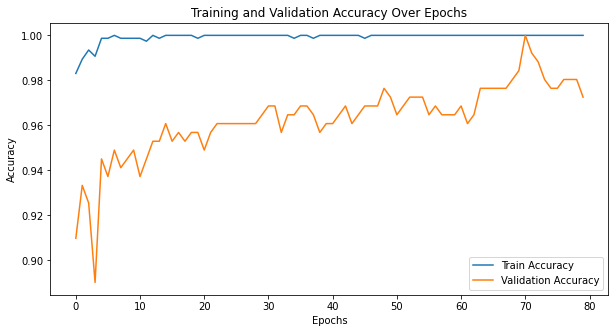

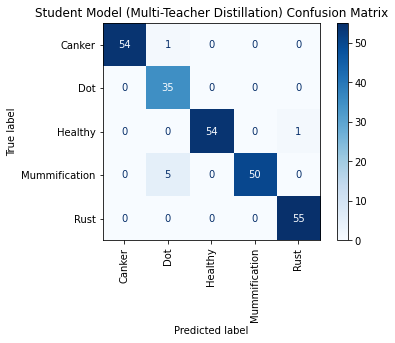

In [23]:
import tensorflow as tf
import numpy as np

# Distillation parameters
alpha = 0.7      # Increase hard label importance
T = 2.0          # Lower temperature
weight_1 = 0.7   # Adjust weights if teacher model 1 is better
weight_2 = 0.3

train_acc = []
val_acc = []
epochs = 80
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_acc = 0
    num_batches = 0

    for x_batch_train, y_batch_train in train_data:
       # Teacher predictions with noise injection
        teacher_preds_1 = teacher_model_1.predict(x_batch_train)
        teacher_preds_1 += np.random.normal(0, 0.01, teacher_preds_1.shape)
        
        teacher_preds_2 = teacher_model_2.predict(x_batch_train)
        teacher_preds_2 += np.random.normal(0, 0.01, teacher_preds_2.shape)
        # Training student model
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            
            # Hard loss with label smoothing
            hard_loss = tf.keras.losses.categorical_crossentropy(y_batch_train, student_predictions, label_smoothing=0.1)
            
            # Soft loss
            combined_teacher_preds = weight_1 * teacher_preds_1 + weight_2 * teacher_preds_2
            soft_loss = tf.keras.losses.KLDivergence()(
                tf.nn.softmax(combined_teacher_preds / T), tf.nn.softmax(student_predictions / T)
            )
            
            # Entropy regularization
            entropy_reg = -tf.reduce_sum(tf.nn.softmax(student_predictions) * tf.math.log(tf.nn.softmax(student_predictions) + 1e-9), axis=-1)
            entropy_loss = 0.01 * tf.reduce_mean(entropy_reg)
            
            # Combined distillation loss
            loss_value = alpha * hard_loss + (1 - alpha) * soft_loss * (T * T) + entropy_loss

        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Batch accuracy
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Epoch accuracy
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Validation evaluation
    val_metrics = student_model.evaluate(valid_data, verbose=0)
    val_acc.append(val_metrics[1])

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_metrics[1] * 100:.2f}%")


# Plot the accuracy graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc, val_acc)

# Plot confusion matrix for the student model
def plot_confusion_matrix(model, test_data, class_names, title):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_data:
        predictions = model.predict(x_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(y_batch.numpy(), axis=1)

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(title)
    plt.show()

plot_confusion_matrix(student_model, valid_data, class_names, "Student Model (Multi-Teacher Distillation) Confusion Matrix")

Epoch 1/20
Epoch 1 - Train Accuracy: 99.09%, Validation Accuracy: 94.90%
Epoch 2/20
Epoch 2 - Train Accuracy: 99.87%, Validation Accuracy: 95.69%
Epoch 3/20
Epoch 3 - Train Accuracy: 100.00%, Validation Accuracy: 96.08%
Epoch 4/20
Epoch 4 - Train Accuracy: 99.87%, Validation Accuracy: 96.08%
Epoch 5/20
Epoch 5 - Train Accuracy: 100.00%, Validation Accuracy: 96.47%
Epoch 6/20
Epoch 6 - Train Accuracy: 100.00%, Validation Accuracy: 95.69%
Epoch 7/20
Epoch 7 - Train Accuracy: 100.00%, Validation Accuracy: 96.47%
Epoch 8/20
Epoch 8 - Train Accuracy: 100.00%, Validation Accuracy: 96.47%
Epoch 9/20
Epoch 9 - Train Accuracy: 100.00%, Validation Accuracy: 96.47%
Epoch 10/20
Epoch 10 - Train Accuracy: 100.00%, Validation Accuracy: 96.08%
Epoch 11/20
Epoch 11 - Train Accuracy: 100.00%, Validation Accuracy: 96.47%
Epoch 12/20
Epoch 12 - Train Accuracy: 100.00%, Validation Accuracy: 96.47%
Epoch 13/20
Epoch 13 - Train Accuracy: 100.00%, Validation Accuracy: 96.47%
Epoch 14/20
Epoch 14 - Train Accu

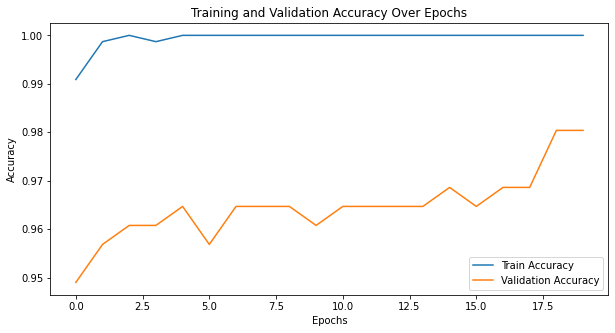

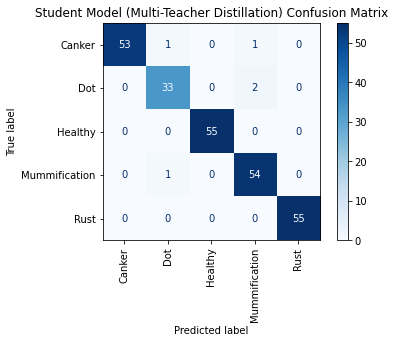

In [15]:
import tensorflow as tf
import numpy as np

# Distillation parameters
alpha = 0.7      # Increase hard label importance
T = 2.0          # Lower temperature
weight_1 = 0.7   # Adjust weights if teacher model 1 is better
weight_2 = 0.3

train_acc = []
val_acc = []
epochs = 20
# Load teacher models
teacher_model_1 = tf.keras.models.load_model("/kaggle/input/xception3/xception_teacher_model (1).h5")
teacher_model_2 = tf.keras.models.load_model("/kaggle/input/inceptionres1/inception_resnet_advanced_model (1).h5")

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_acc = 0
    num_batches = 0

    for x_batch_train, y_batch_train in train_data:
       # Teacher predictions with noise injection
        teacher_preds_1 = teacher_model_1.predict(x_batch_train)
        teacher_preds_1 += np.random.normal(0, 0.01, teacher_preds_1.shape)
        
        teacher_preds_2 = teacher_model_2.predict(x_batch_train)
        teacher_preds_2 += np.random.normal(0, 0.01, teacher_preds_2.shape)
        # Training student model
        with tf.GradientTape() as tape:
            student_predictions = student_model(x_batch_train, training=True)
            
            # Hard loss with label smoothing
            hard_loss = tf.keras.losses.categorical_crossentropy(y_batch_train, student_predictions, label_smoothing=0.1)
            
            # Soft loss
            combined_teacher_preds = weight_1 * teacher_preds_1 + weight_2 * teacher_preds_2
            soft_loss = tf.keras.losses.KLDivergence()(
                tf.nn.softmax(combined_teacher_preds / T), tf.nn.softmax(student_predictions / T)
            )
            
            # Entropy regularization
            entropy_reg = -tf.reduce_sum(tf.nn.softmax(student_predictions) * tf.math.log(tf.nn.softmax(student_predictions) + 1e-9), axis=-1)
            entropy_loss = 0.01 * tf.reduce_mean(entropy_reg)
            
            # Combined distillation loss
            loss_value = alpha * hard_loss + (1 - alpha) * soft_loss * (T * T) + entropy_loss

        grads = tape.gradient(loss_value, student_model.trainable_weights)
        student_model.optimizer.apply_gradients(zip(grads, student_model.trainable_weights))

        # Batch accuracy
        batch_accuracy = np.mean(np.argmax(student_predictions, axis=1) == np.argmax(y_batch_train, axis=1))
        total_train_acc += batch_accuracy
        num_batches += 1

    # Epoch accuracy
    avg_train_acc = total_train_acc / num_batches
    train_acc.append(avg_train_acc)

    # Validation evaluation
    val_metrics = student_model.evaluate(valid_data, verbose=0)
    val_acc.append(val_metrics[1])

    print(f"Epoch {epoch + 1} - Train Accuracy: {avg_train_acc * 100:.2f}%, Validation Accuracy: {val_metrics[1] * 100:.2f}%")


# Plot the accuracy graph
def plot_accuracy(train_acc, val_acc):
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc, label='Train Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_accuracy(train_acc, val_acc)

# Plot confusion matrix for the student model
def plot_confusion_matrix(model, test_data, class_names, title):
    y_true = []
    y_pred = []

    for x_batch, y_batch in test_data:
        predictions = model.predict(x_batch)
        predicted_labels = np.argmax(predictions, axis=1)
        true_labels = np.argmax(y_batch.numpy(), axis=1)

        y_true.extend(true_labels)
        y_pred.extend(predicted_labels)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(title)
    plt.show()

plot_confusion_matrix(student_model, valid_data, class_names, "Student Model (Multi-Teacher Distillation) Confusion Matrix")